<div style="background: linear-gradient(135deg, #0F6E56 0%, #1D9E75 50%, #5DCAA5 100%);
            padding: 40px 30px; border-radius: 12px; margin-bottom: 10px;">
  <h1 style="color: white; font-size: 2.2em; margin: 0 0 8px 0; font-weight: 700;">
    🌾 Prédiction du Rendement du Riz
  </h1>
  <h2 style="color: rgba(255,255,255,0.85); font-size: 1.2em; margin: 0 0 16px 0; font-weight: 400;">
    Approche Machine Learning & Deep Learning — Comparaison complète
  </h2>
  <div style="color: rgba(255,255,255,0.7); font-size: 0.9em; line-height: 1.8;">
    <b>Dataset</b> : rice_yield_data.csv — 2789 observations · 45 variables brutes · 74 features finales<br>
    <b>Cible</b>   : Paddy yield (en kg) — régression continue<br>
    <b>Stack</b>   : Python · Pandas · Scikit-learn · TensorFlow/Keras · SHAP · Matplotlib · Seaborn
  </div>
</div>

## Table des matières

| # | Section | Description |
|---|---------|-------------|
| 0 | [Configuration & Imports](#0) | TensorFlow · sklearn · palette · seed global |
| 1 | [Chargement & EDA](#1) | Distributions · corrélations · profil météo |
| 2 | [Préprocessing](#2) | Feature engineering · encodage · scaling — **cellule unique idempotente** |
| 3 | [ML Baseline](#3) | Ridge · Lasso · SVR · RF · Gradient Boosting |
| 4 | [Deep Learning TF — Architectures & Entraînement](#4) | MLP Standard · Résiduel · Wide + callbacks |
| 5 | [Deep Learning TF — Visualisations](#5) | Loss curves · scatter · résidus |
| 6 | [Comparaison Finale](#6) | Dashboard ML vs DL TF |
| 7 | [Interprétabilité](#7) | Feature importance · analyse résidus comparée |
| 8 | [Inférence Production](#8) | predict_yield() unifié ML + TF · rapport final |

---
> **Reproductibilité** : chaque section peut être relancée indépendamment.
> La cellule de preprocessing recharge toujours le CSV depuis le disque — aucun état résiduel.


---
<a id='0'></a>
## ⚙️ Section 0 — Configuration & Imports

Installation des dépendances et configuration globale du projet.
Toutes les constantes (seed, chemins, couleurs) sont centralisées ici pour la reproductibilité.


In [ ]:
# ─── Installation (décommenter si nécessaire) ────────────────────────────────
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn scipy

# ─── Imports standard ────────────────────────────────────────────────────────
import os
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scipy.stats as stats

# ─── Visualisation ───────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ─── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing   import StandardScaler
from sklearn.metrics         import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model    import Ridge, Lasso
from sklearn.svm             import SVR
from sklearn.ensemble        import RandomForestRegressor, GradientBoostingRegressor

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION GLOBALE
# ─────────────────────────────────────────────────────────────────────────────
RANDOM_SEED = 42
TEST_SIZE   = 0.20
CV_FOLDS    = 5
DATA_PATH   = "data/rice_yield_data_2.csv"
TARGET      = "Paddy yield(in Kg)"
ARTEFACT_DIR= "artefacts"

# Reproductibilité totale
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

os.makedirs(ARTEFACT_DIR, exist_ok=True)
os.makedirs("checkpoints",  exist_ok=True)
os.makedirs("saved_models", exist_ok=True)

# ─── Palette de couleurs ─────────────────────────────────────────────────────
PALETTE = {
    "primary"   : "#1D9E75",
    "secondary" : "#7F77DD",
    "accent"    : "#EF9F27",
    "coral"     : "#D85A30",
    "blue"      : "#378ADD",
    "dark"      : "#2C2C2A",
    "gray"      : "#888780",
    "bg"        : "#F8F8F5",
}
MODEL_COLORS = {
    "Ridge"             : "#378ADD",
    "Lasso"             : "#E24B4A",
    "SVR"               : "#1D9E75",
    "Random Forest"     : "#0F6E56",
    "Gradient Boosting" : "#D85A30",
    "MLP_Standard"      : "#1D9E75",
    "MLP_Residual"      : "#7F77DD",
    "MLP_Wide"          : "#EF9F27",
}

# ─── Style matplotlib ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : PALETTE["bg"],
    "axes.facecolor"    : PALETTE["bg"],
    "axes.edgecolor"    : "#B4B2A9",
    "axes.labelcolor"   : PALETTE["dark"],
    "xtick.color"       : PALETTE["dark"],
    "ytick.color"       : PALETTE["dark"],
    "text.color"        : PALETTE["dark"],
    "font.family"       : "DejaVu Sans",
    "font.size"         : 10,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "axes.grid"         : True,
    "grid.color"        : "#D3D1C7",
    "grid.linewidth"    : 0.5,
    "figure.dpi"        : 120,
})

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {tf.config.list_physical_devices('GPU') or 'CPU uniquement'}")
print(f"Seed       : {RANDOM_SEED}")
print(f"Test size  : {TEST_SIZE:.0%}  |  CV folds : {CV_FOLDS}")


TensorFlow : 2.21.0
GPU        : CPU uniquement
Seed       : 42
Test size  : 20%  |  CV folds : 5


---
<a id='1'></a>
## 📊 Section 1 — Chargement & Analyse Exploratoire (EDA)

> **Règle d'or** : *Ne jamais modéliser sans comprendre ses données.*
> L'EDA révèle les distributions, les corrélations, les valeurs aberrantes
> et les relations cachées qui guideront toutes les décisions de modélisation.


In [58]:
# ─── 1.1 Chargement ──────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, sep=";")
df.rename(columns={"Hectares ": "Hectares"}, inplace=True)

print("═" * 55)
print("APERÇU DU DATASET")
print("═" * 55)
print(f"  Dimensions    : {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f"  Mémoire       : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")
print(f"  Doublons      : {df.duplicated().sum()}")
print(f"  Valeurs NaN   : {df.isnull().sum().sum()}")
print()
df.head()


═══════════════════════════════════════════════════════
APERÇU DU DATASET
═══════════════════════════════════════════════════════
  Dimensions    : 2789 lignes × 45 colonnes
  Mémoire       : 2144.9 KB
  Doublons      : 451
  Valeurs NaN   : 0



,Hectares,Agriblock,Variety,Soil Types,Seedrate(in Kg),LP_Mainfield(in Tonnes),Nursery,Nursery area (Cents),LP_nurseryarea(in Tonnes),DAP_20days,...,Wind Direction_D1_D30,Wind Direction_D31_D60,Wind Direction_D61_D90,Wind Direction_D91_D120,Relative Humidity_D1_D30,Relative Humidity_D31_D60,Relative Humidity_D61_D90,Relative Humidity_D91_D120,Trash(in bundles),Paddy yield(in Kg)
0,6,Cuddalore,CO_43,alluvial,150,75.0,dry,120,6,240,...,SW,W,NNW,WSW,72.0,78,88,85,540,35028
1,6,Kurinjipadi,ponmani,clay,150,75.0,wet,120,6,240,...,NW,S,SE,SSE,64.6,85,84,87,600,35412
2,6,Panruti,delux ponni,alluvial,150,75.0,dry,120,6,240,...,ENE,NE,NNE,W,85.0,96,84,79,600,36300
3,6,Kallakurichi,CO_43,clay,150,75.0,wet,120,6,240,...,W,WNW,SE,S,88.5,95,81,84,540,35016
4,6,Sankarapuram,ponmani,alluvial,150,75.0,dry,120,6,240,...,SSE,W,SW,NW,72.7,91,83,81,600,34044


In [59]:
# ─── 1.2 Types et valeurs uniques ─────────────────────────────────────────────
print("TYPES DE VARIABLES")
print("─" * 40)
type_summary = pd.DataFrame({
    "type"    : df.dtypes,
    "nunique" : df.nunique(),
    "null%"   : (df.isnull().mean() * 100).round(2),
    "exemple" : [str(df[c].dropna().iloc[0]) if len(df[c].dropna()) > 0 else "—"
                 for c in df.columns]
})
print(type_summary.to_string())


TYPES DE VARIABLES
────────────────────────────────────────
                                       type  nunique  null%    exemple
Hectares                              int64        6    0.0          6
Agriblock                               str        6    0.0  Cuddalore
Variety                                 str        3    0.0      CO_43
Soil Types                              str        2    0.0   alluvial
Seedrate(in Kg)                       int64        6    0.0        150
LP_Mainfield(in Tonnes)             float64        6    0.0       75.0
Nursery                                 str        2    0.0        dry
Nursery area (Cents)                  int64        6    0.0        120
LP_nurseryarea(in Tonnes)             int64        6    0.0          6
DAP_20days                            int64        6    0.0        240
Weed28D_thiobencarb                   int64        6    0.0         12
Urea_40Days                         float64        6    0.0     162.78
Potassh_50Days   

In [60]:
# ─── 1.3 Statistiques descriptives ───────────────────────────────────────────
print("STATISTIQUES DESCRIPTIVES — Variables numériques")
df.describe().T.style.background_gradient(cmap="YlGn", subset=["mean", "std"])


STATISTIQUES DESCRIPTIVES — Variables numériques


,count,mean,std,min,25%,50%,75%,max
Hectares,2789.000000,3.717461,1.437777,1.000000,3.000000,4.000000,5.000000,6.000000
Seedrate(in Kg),2789.000000,92.936536,35.944420,25.000000,75.000000,100.000000,125.000000,150.000000
LP_Mainfield(in Tonnes),2789.000000,46.468268,17.972210,12.500000,37.500000,50.000000,62.500000,75.000000
Nursery area (Cents),2789.000000,74.349229,28.755536,20.000000,60.000000,80.000000,100.000000,120.000000
LP_nurseryarea(in Tonnes),2789.000000,3.717461,1.437777,1.000000,3.000000,4.000000,5.000000,6.000000
DAP_20days,2789.000000,148.698458,57.511072,40.000000,120.000000,160.000000,200.000000,240.000000
Weed28D_thiobencarb,2789.000000,7.434923,2.875554,2.000000,6.000000,8.000000,10.000000,12.000000
Urea_40Days,2789.000000,100.854729,39.006885,27.130000,81.390000,108.520000,135.650000,162.780000
Potassh_50Days,2789.000000,38.587250,14.924123,10.380000,31.140000,41.520000,51.900000,62.280000
Micronutrients_70Days,2789.000000,55.761922,21.566652,15.000000,45.000000,60.000000,75.000000,90.000000


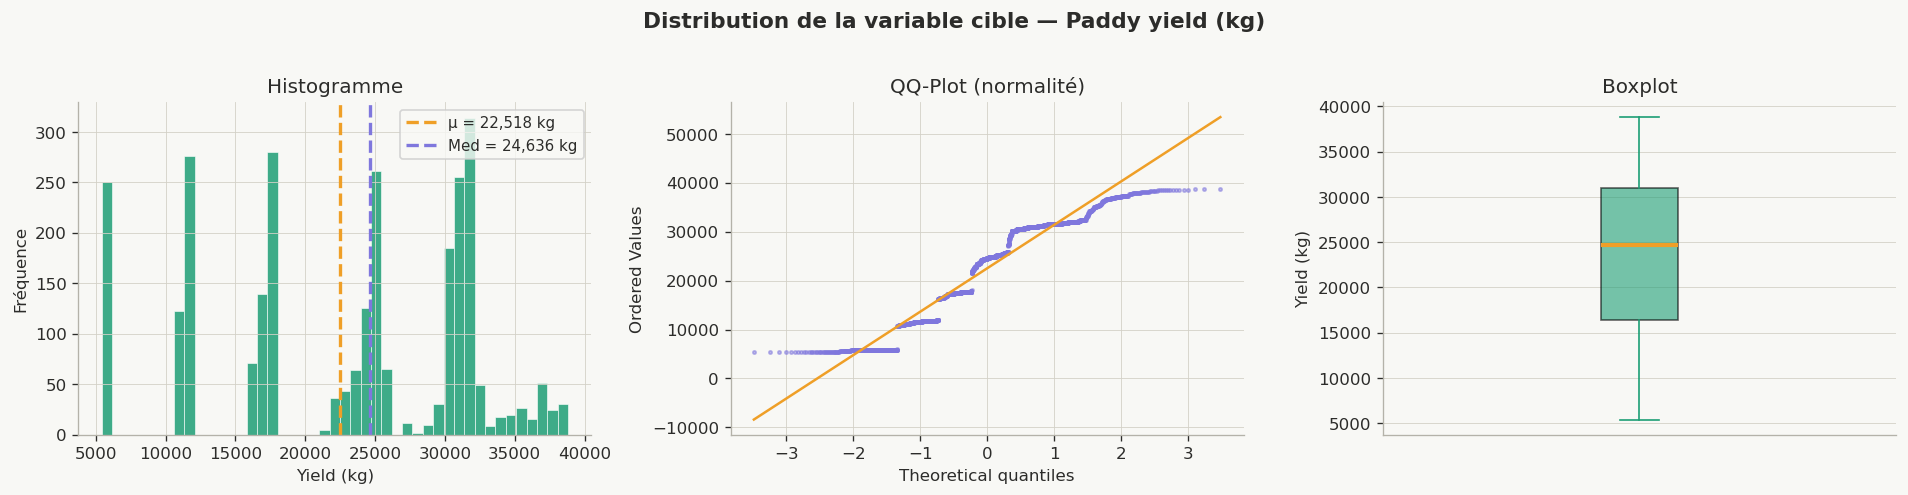


  Skewness : -0.322  (légèrement asymétrique)
  Kurtosis : -1.071
  Range    : [5,410 — 38,814] kg


In [61]:
# ─── 1.4 Distribution de la variable cible ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Distribution de la variable cible — Paddy yield (kg)",
             fontsize=13, fontweight="bold", y=1.02)

y = df[TARGET]

# Histogramme
axes[0].hist(y, bins=45, color=PALETTE["primary"], alpha=0.85, edgecolor="white", lw=0.4)
axes[0].axvline(y.mean(),   color=PALETTE["accent"],    lw=2, ls="--", label=f"μ = {y.mean():,.0f} kg")
axes[0].axvline(y.median(), color=PALETTE["secondary"], lw=2, ls="--", label=f"Med = {y.median():,.0f} kg")
axes[0].set_xlabel("Yield (kg)"); axes[0].set_ylabel("Fréquence")
axes[0].set_title("Histogramme"); axes[0].legend(fontsize=9)

# QQ-plot
stats.probplot(y, dist="norm", plot=axes[1])
axes[1].set_title("QQ-Plot (normalité)")
axes[1].get_lines()[0].set(color=PALETTE["secondary"], markersize=2, alpha=0.5)
axes[1].get_lines()[1].set(color=PALETTE["accent"], lw=1.5)

# Boxplot
axes[2].boxplot(y, vert=True, patch_artist=True,
    medianprops=dict(color=PALETTE["accent"], lw=2.5),
    boxprops=dict(facecolor=PALETTE["primary"], alpha=0.6),
    whiskerprops=dict(color=PALETTE["primary"]),
    capprops=dict(color=PALETTE["primary"]),
    flierprops=dict(marker="o", color=PALETTE["secondary"], markersize=3, alpha=0.4))
axes[2].set_title("Boxplot"); axes[2].set_ylabel("Yield (kg)"); axes[2].set_xticks([])

plt.tight_layout()
plt.show()

print(f"\n  Skewness : {y.skew():.3f}  ({'légèrement asymétrique' if abs(y.skew()) < 0.5 else 'asymétrique'})")
print(f"  Kurtosis : {y.kurtosis():.3f}")
print(f"  Range    : [{y.min():,.0f} — {y.max():,.0f}] kg")


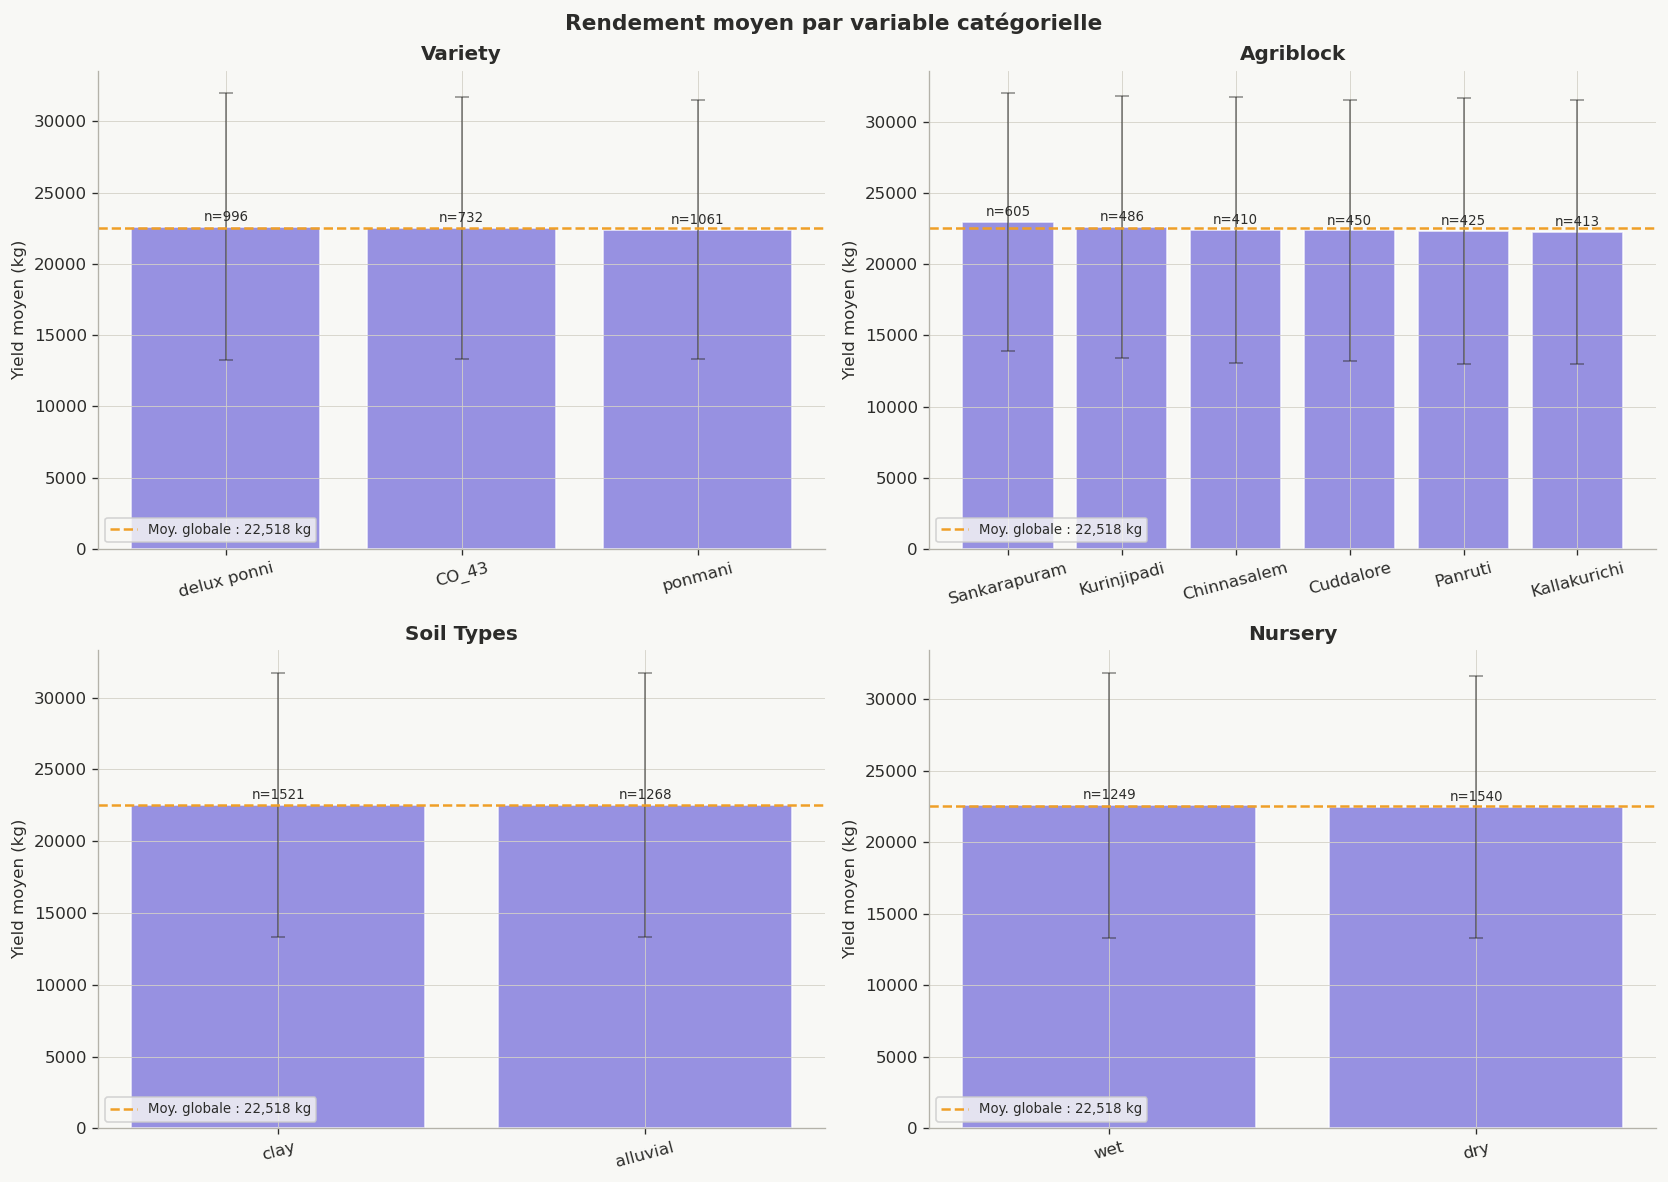

In [62]:
# ─── 1.5 Variables catégorielles ──────────────────────────────────────────────
cat_cols = ["Variety", "Agriblock", "Soil Types", "Nursery"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Rendement moyen par variable catégorielle", fontsize=13, fontweight="bold")

for ax, col in zip(axes.ravel(), cat_cols):
    stats_cat = df.groupby(col)[TARGET].agg(["mean", "std", "count"]).sort_values("mean", ascending=False)
    bars = ax.bar(stats_cat.index, stats_cat["mean"],
                  yerr=stats_cat["std"], capsize=4,
                  color=PALETTE["secondary"], alpha=0.8, edgecolor="white",
                  error_kw={"ecolor": PALETTE["dark"], "lw": 1.2, "alpha": 0.5})
    ax.axhline(df[TARGET].mean(), color=PALETTE["accent"], lw=1.5, ls="--",
               label=f"Moy. globale : {df[TARGET].mean():,.0f} kg")
    for bar, (_, row) in zip(bars, stats_cat.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f"n={int(row['count'])}", ha="center", va="bottom", fontsize=8)
    ax.set_title(f"{col}", fontweight="bold"); ax.legend(fontsize=8)
    ax.set_ylabel("Yield moyen (kg)"); ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


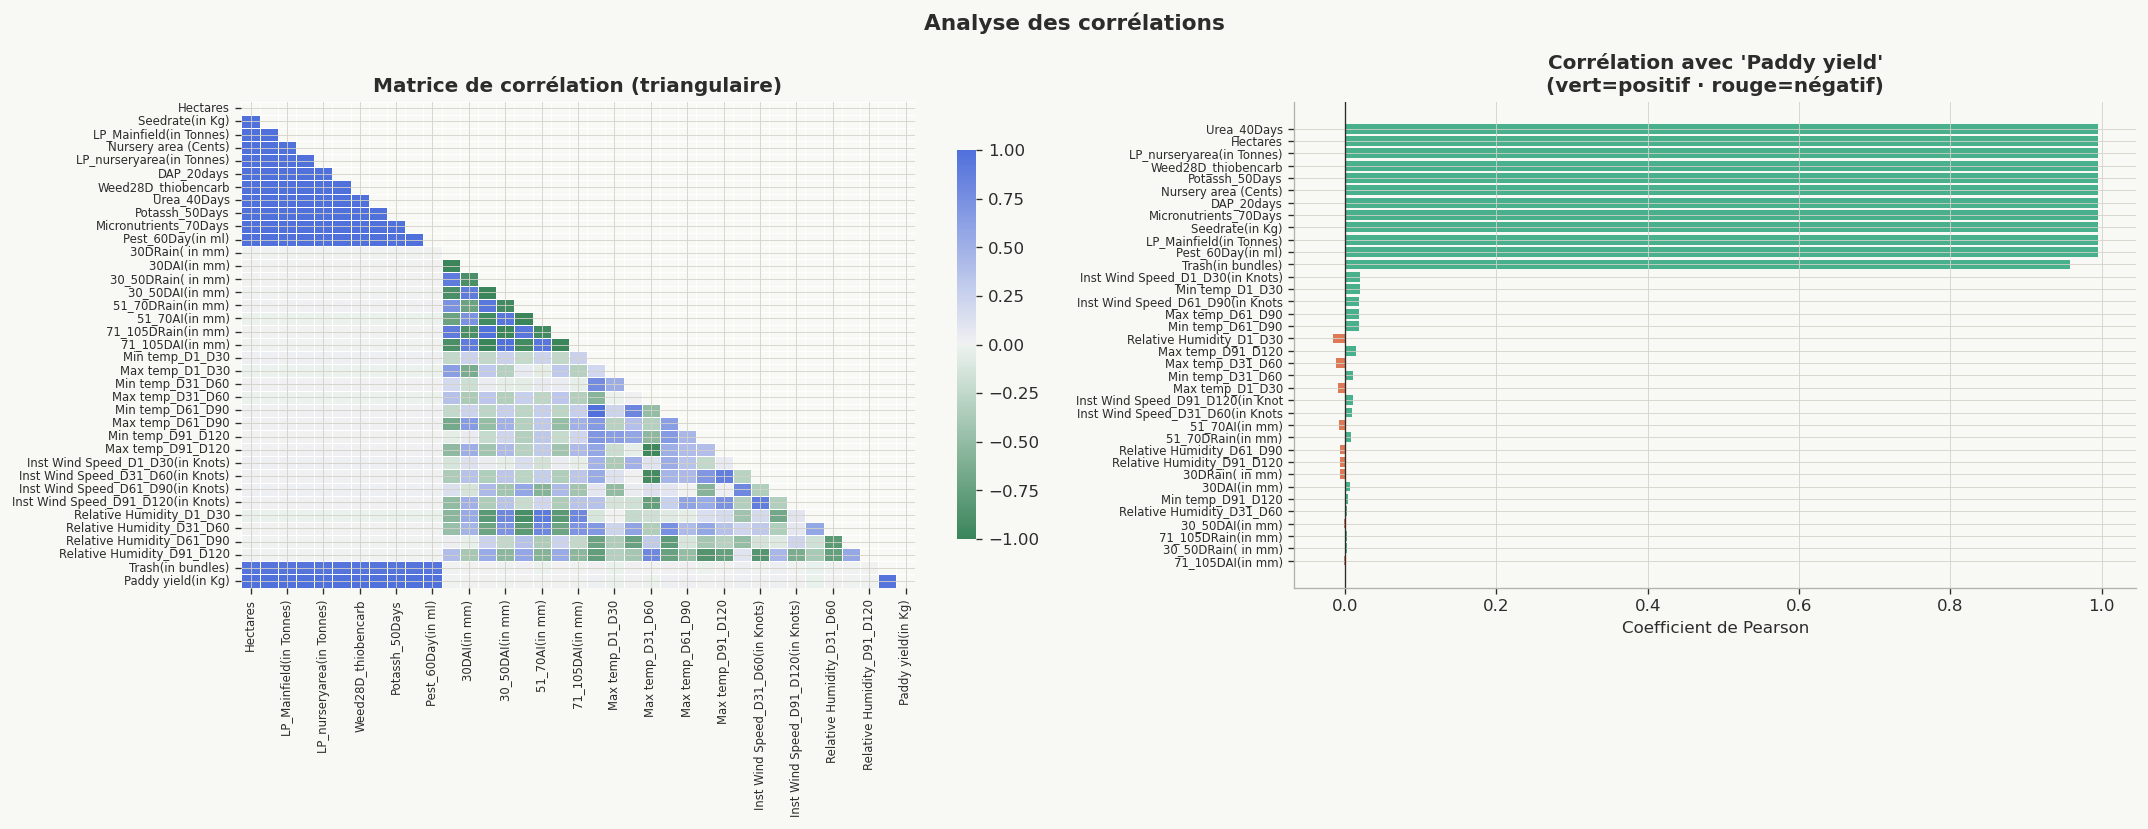


⚠  OBSERVATION CRITIQUE :
   Les variables d'intrants (DAP, Urea, Seedrate...) ont r=0.995 avec le target.
   → Elles sont PROPORTIONNELLES aux hectares, pas informatifs en soi.
   → Action : les normaliser par hectare dans le préprocessing.


In [63]:
# ─── 1.6 Matrice de corrélation & top corrélations avec la cible ─────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
corr = df[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Analyse des corrélations", fontsize=13, fontweight="bold")

# Heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(142, 260, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, ax=axes[0],
            annot=False, square=False, linewidths=0.3,
            cbar_kws={"shrink": 0.8}, vmin=-1, vmax=1)
axes[0].set_title("Matrice de corrélation (triangulaire)", fontweight="bold")
axes[0].tick_params(labelsize=7)

# Top corrélations avec la cible
corr_target = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=True)
colors_bar  = [PALETTE["primary"] if v > 0 else PALETTE["coral"] for v in corr_target.values]
axes[1].barh(range(len(corr_target)), corr_target.values, color=colors_bar, alpha=0.8)
axes[1].set_yticks(range(len(corr_target)))
axes[1].set_yticklabels([c[:32] for c in corr_target.index], fontsize=7)
axes[1].axvline(0, color=PALETTE["dark"], lw=0.8)
axes[1].set_title("Corrélation avec 'Paddy yield'\n(vert=positif · rouge=négatif)",
                   fontweight="bold")
axes[1].set_xlabel("Coefficient de Pearson")

plt.tight_layout()
plt.show()

print("\n⚠  OBSERVATION CRITIQUE :")
print("   Les variables d'intrants (DAP, Urea, Seedrate...) ont r=0.995 avec le target.")
print("   → Elles sont PROPORTIONNELLES aux hectares, pas informatifs en soi.")
print("   → Action : les normaliser par hectare dans le préprocessing.")


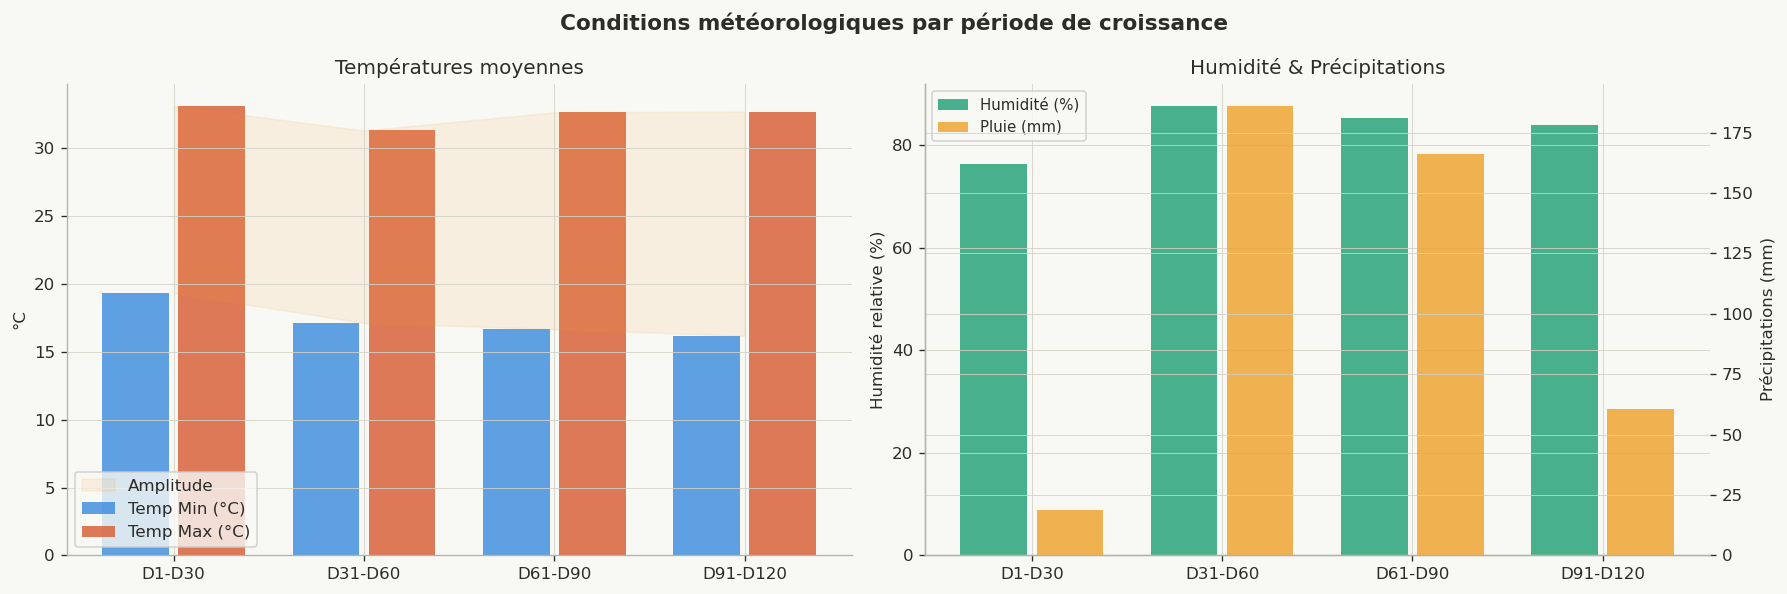

In [64]:
# ─── 1.7 Analyse météo temporelle ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Conditions météorologiques par période de croissance", fontsize=13, fontweight="bold")

periods     = ["D1-D30", "D31-D60", "D61-D90", "D91-D120"]
temp_min    = ["Min temp_D1_D30","Min temp_D31_D60","Min temp_D61_D90","Min temp_D91_D120"]
temp_max    = ["Max temp_D1_D30","Max temp_D31_D60","Max temp_D61_D90","Max temp_D91_D120"]
hum_cols    = ["Relative Humidity_D1_D30","Relative Humidity_D31_D60",
               "Relative Humidity_D61_D90","Relative Humidity_D91_D120"]
rain_cols   = ["30DRain( in mm)","30_50DRain( in mm)","51_70DRain(in mm)","71_105DRain(in mm)"]
x = np.arange(len(periods))

# Températures
axes[0].bar(x - 0.2, df[temp_min].mean(), 0.35, label="Temp Min (°C)",
            color=PALETTE["blue"], alpha=0.8)
axes[0].bar(x + 0.2, df[temp_max].mean(), 0.35, label="Temp Max (°C)",
            color=PALETTE["coral"], alpha=0.8)
axes[0].fill_between(x, df[temp_min].mean(), df[temp_max].mean(),
                     alpha=0.1, color=PALETTE["accent"], label="Amplitude")
axes[0].set_xticks(x); axes[0].set_xticklabels(periods)
axes[0].set_title("Températures moyennes"); axes[0].set_ylabel("°C"); axes[0].legend()

# Humidité + Pluie
ax_twin = axes[1].twinx()
axes[1].bar(x - 0.2, df[hum_cols].mean(), 0.35, label="Humidité (%)",
            color=PALETTE["primary"], alpha=0.8)
ax_twin.bar(x + 0.2, df[rain_cols].mean(), 0.35, label="Pluie (mm)",
            color=PALETTE["accent"], alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(periods)
axes[1].set_ylabel("Humidité relative (%)"); ax_twin.set_ylabel("Précipitations (mm)")
axes[1].set_title("Humidité & Précipitations")
lines1, lbl1 = axes[1].get_legend_handles_labels()
lines2, lbl2 = ax_twin.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, lbl1 + lbl2, fontsize=9)

plt.tight_layout()
plt.show()


---
<a id='2'></a>
## 🔧 Section 2 — Préprocessing & Feature Engineering

> Le préprocessing est souvent la partie **la plus impactante** d'un projet ML.
> Un bon feature engineering peut faire passer un modèle simple de 0.85 à 0.99 de R².

### Stratégie adoptée
1. **Normalisation par hectare** — les intrants sont proportionnels à la taille de la parcelle → on les convertit en doses agronomiques (kg/ha)
2. **Features dérivées** — amplitude thermique, déficit hydrique, stress thermique (T × HR)
3. **Encodage OHE** — variables nominales sans ordre (Variety, Agriblock, Soil, Nursery)
4. **Encodage cyclique sin/cos** — direction du vent (variable angulaire, 0°=360°)
5. **Scaling StandardScaler** — fitté **uniquement** sur le train pour éviter le data leakage


In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2 — PREPROCESSING COMPLET (cellule unique, idempotente)
#
# Design pattern : on recharge df depuis le CSV à chaque exécution.
# → Le notebook peut être relancé cellule par cellule sans KeyError.
# ══════════════════════════════════════════════════════════════════════════════

# ─── 2.0 Rechargement propre du DataFrame ─────────────────────────────────
df = pd.read_csv(DATA_PATH, sep=";")
df.rename(columns={"Hectares ": "Hectares"}, inplace=True)
print(f"DataFrame rechargé — shape initiale : {df.shape}")

# ─── 2.1 Normalisation des intrants par hectare ───────────────────────────
# Ces colonnes ont r=0.995 avec le target car elles sont = Hectares × constante.
# En les divisant par Hectares, on extrait la dose agronomique réelle (kg/ha).
INTRANT_COLS = [
    "Seedrate(in Kg)", "LP_Mainfield(in Tonnes)", "Nursery area (Cents)",
    "LP_nurseryarea(in Tonnes)", "DAP_20days", "Weed28D_thiobencarb",
    "Urea_40Days", "Potassh_50Days", "Micronutrients_70Days", "Pest_60Day(in ml)",
]
for col in INTRANT_COLS:
    df[col + "_per_ha"] = df[col] / df["Hectares"]
df.drop(columns=INTRANT_COLS, inplace=True)
print(f"✓ {len(INTRANT_COLS)} intrants normalisés /ha  →  shape : {df.shape}")

# ─── 2.2 Feature Engineering météo ───────────────────────────────────────
TEMP_PERIODS = ["D1_D30", "D31_D60", "D61_D90", "D91_D120"]
HUM_MAP = {
    "D1_D30" : "Relative Humidity_D1_D30",
    "D31_D60": "Relative Humidity_D31_D60",
    "D61_D90": "Relative Humidity_D61_D90",
    "D91_D120":"Relative Humidity_D91_D120",
}
for p in TEMP_PERIODS:
    min_c, max_c = f"Min temp_{p}", f"Max temp_{p}"
    df[f"Temp_Amplitude_{p}"] = df[max_c] - df[min_c]       # stress jour/nuit
    df[f"Temp_Mean_{p}"]      = (df[max_c] + df[min_c]) / 2  # bilan thermique
    df[f"TempHum_Stress_{p}"] = df[f"Temp_Mean_{p}"] * df[HUM_MAP[p]] / 100

rain_cols = ["30DRain( in mm)","30_50DRain( in mm)","51_70DRain(in mm)","71_105DRain(in mm)"]
dai_cols  = ["30DAI(in mm)","30_50DAI(in mm)","51_70AI(in mm)","71_105DAI(in mm)"]
df["Total_Rain_mm"] = df[rain_cols].sum(axis=1)
df["Total_DAI_mm"]  = df[dai_cols].sum(axis=1)
df["Rain_Deficit"]  = df["Total_DAI_mm"] - df["Total_Rain_mm"]   # besoin hydrique non couvert

hum_cols  = ["Relative Humidity_D1_D30","Relative Humidity_D31_D60",
             "Relative Humidity_D61_D90","Relative Humidity_D91_D120"]
wind_cols = ["Inst Wind Speed_D1_D30(in Knots)","Inst Wind Speed_D31_D60(in Knots)",
             "Inst Wind Speed_D61_D90(in Knots)","Inst Wind Speed_D91_D120(in Knots)"]
df["Mean_Humidity"]   = df[hum_cols].mean(axis=1)
df["Mean_Wind_Speed"] = df[wind_cols].mean(axis=1)
print(f"✓ Features météo dérivées      →  shape : {df.shape}")

# ─── 2.3 Encodage des variables catégorielles ─────────────────────────────
# One-Hot Encoding — variables nominales sans ordre naturel
OHE_COLS = ["Agriblock", "Variety", "Soil Types", "Nursery"]
df = pd.get_dummies(df, columns=OHE_COLS, drop_first=False, dtype=int)

# Encodage cyclique sin/cos — direction du vent (variable angulaire : 0°=360°)
WIND_DIR_MAP = {
    "N":0,"NNE":22.5,"NE":45,"ENE":67.5,"E":90,"ESE":112.5,"SE":135,"SSE":157.5,
    "S":180,"SSW":202.5,"SW":225,"WSW":247.5,"W":270,"WNW":292.5,"NW":315,"NNW":337.5,
}
WIND_DIR_COLS = ["Wind Direction_D1_D30","Wind Direction_D31_D60",
                 "Wind Direction_D61_D90","Wind Direction_D91_D120"]
for col in WIND_DIR_COLS:
    angles = df[col].map(WIND_DIR_MAP).fillna(0)
    rad    = np.deg2rad(angles)
    df[col + "_sin"] = np.sin(rad).round(6)
    df[col + "_cos"] = np.cos(rad).round(6)
    df.drop(columns=[col], inplace=True)

print(f"✓ OHE + encodage cyclique vent →  shape : {df.shape}")

# ─── 2.4 Séparation features / target + train/test split ─────────────────
FEATURE_COLS = [c for c in df.columns if c != TARGET]
X = df[FEATURE_COLS].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED
)
print(f"\n✓ Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"  Features : {len(FEATURE_COLS)}  |  Target range : [{y.min():,.0f} — {y.max():,.0f}] kg")

# ─── 2.5 Standardisation (StandardScaler) ────────────────────────────────
# RÈGLE IMPÉRATIVE : fit() uniquement sur train → évite le data leakage.
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)            # ← transform UNIQUEMENT

y_train_sc = scaler_y.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test.reshape(-1, 1)).ravel()

print(f"\n✓ StandardScaler — X: μ={X_train_sc.mean():.4f}, σ={X_train_sc.std():.4f}")
print(f"                  — y: μ={y_train_sc.mean():.4f}, σ={y_train_sc.std():.4f}")
print(f"  σ(y) = {scaler_y.scale_[0]:.2f} kg  (utilisé pour reconvertir RMSE en kg)")

# ─── 2.6 Sauvegarde des artefacts ─────────────────────────────────────────
artefacts = {
    "X_train": X_train, "X_test": X_test,
    "y_train": y_train, "y_test": y_test,
    "X_train_sc": X_train_sc, "X_test_sc": X_test_sc,
    "y_train_sc": y_train_sc, "y_test_sc": y_test_sc,
    "scaler_X": scaler_X, "scaler_y": scaler_y,
    "feature_cols": FEATURE_COLS,
}
for name, obj in artefacts.items():
    with open(f"{ARTEFACT_DIR}/{name}.pkl", "wb") as f:
        pickle.dump(obj, f)

print(f"\n✓ {len(artefacts)} artefacts sauvegardés → ./{ARTEFACT_DIR}/")
print("\n" + "─"*55)
print("RÉSUMÉ PREPROCESSING")
print("─"*55)
print(f"  Dataset initial    : 2789 obs × 45 colonnes")
print(f"  Features finales   : {len(FEATURE_COLS)}")
print(f"  Intrants /ha       : {len(INTRANT_COLS)} features normalisées")
print(f"  Features météo     : amplitude, moyenne, stress, agrégats")
print(f"  Encodage OHE       : Agriblock×6, Variety×3, Soil×2, Nursery×2")
print(f"  Encodage cyclique  : sin/cos × 4 directions de vent")
print(f"  Split              : {X_train.shape[0]} train / {X_test.shape[0]} test")
print(f"  Scaling            : StandardScaler fitté sur train uniquement")


DataFrame rechargé — shape initiale : (2789, 45)
✓ 10 intrants normalisés /ha  →  shape : (2789, 45)
✓ Features météo dérivées      →  shape : (2789, 62)
✓ OHE + encodage cyclique vent →  shape : (2789, 75)

✓ Train : (2231, 74)  |  Test : (558, 74)
  Features : 74  |  Target range : [5,410 — 38,814] kg

✓ StandardScaler — X: μ=-0.0000, σ=0.9300
                  — y: μ=-0.0000, σ=1.0000
  σ(y) = 9244.74 kg  (utilisé pour reconvertir RMSE en kg)

✓ 11 artefacts sauvegardés → ./artefacts/

───────────────────────────────────────────────────────
RÉSUMÉ PREPROCESSING
───────────────────────────────────────────────────────
  Dataset initial    : 2789 obs × 45 colonnes
  Features finales   : 74
  Intrants /ha       : 10 features normalisées
  Features météo     : amplitude, moyenne, stress, agrégats
  Encodage OHE       : Agriblock×6, Variety×3, Soil×2, Nursery×2
  Encodage cyclique  : sin/cos × 4 directions de vent
  Split              : 2231 train / 558 test
  Scaling            : Standar

---
<a id='3'></a>
## 🤖 Section 3 — Modèles ML Baseline

> Avant d'aller vers le Deep Learning, on établit un **baseline solide** avec des modèles
> classiques. C'est une bonne pratique : si un Random Forest atteint déjà R²=0.99,
> la complexité d'un réseau de neurones n'est peut-être pas justifiée.

### Modèles testés
| Modèle | Paradigme | Scaled | Force |
|--------|-----------|--------|-------|
| **Ridge** | Linéaire + L2 | ✓ | Interprétable, rapide |
| **Lasso** | Linéaire + L1 | ✓ | Sélection de features |
| **SVR** | Kernel RBF | ✓ | Excellent sur données moyennes |
| **Random Forest** | Ensemble bagging | ✗ | Robuste, feature importance |
| **Gradient Boosting** | Ensemble boosting | ✗ | Très précis |


In [66]:
# ─── 3.1 Définition des modèles ───────────────────────────────────────────────
MODELS = {
    "Ridge": {
        "model": Ridge(alpha=1.0),
        "scaled": True, "color": "#378ADD",
    },
    "Lasso": {
        "model": Lasso(alpha=0.5, max_iter=5000),
        "scaled": True, "color": "#E24B4A",
    },
    "SVR": {
        "model": SVR(kernel="rbf", C=10, epsilon=0.1, gamma="scale"),
        "scaled": True, "color": "#1D9E75",
    },
    "Random Forest": {
        "model": RandomForestRegressor(
            n_estimators=200, max_depth=None, min_samples_leaf=2,
            n_jobs=-1, random_state=RANDOM_SEED),
        "scaled": False, "color": "#0F6E56",
    },
    "Gradient Boosting": {
        "model": GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=5,
            subsample=0.8, random_state=RANDOM_SEED),
        "scaled": False, "color": "#D85A30",
    },
}

kf     = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
sigma  = scaler_y.scale_[0]
results_ml = {}

print(f"{'Modèle':<22} {'RMSE':>10} {'MAE':>10} {'R²':>8} {'CV RMSE':>12} {'Temps':>7}")
print("─" * 68)

for name, cfg in MODELS.items():
    model  = cfg["model"]
    Xtr    = X_train_sc if cfg["scaled"] else X_train
    ytr    = y_train_sc if cfg["scaled"] else y_train
    Xte    = X_test_sc  if cfg["scaled"] else X_test

    t0 = time.time()

    # Cross-validation
    cv_scores = cross_val_score(model, Xtr, ytr,
                                cv=kf, scoring="neg_mean_squared_error", n_jobs=-1)
    cv_rmse_kg = np.sqrt(-cv_scores) * (sigma if cfg["scaled"] else 1)

    # Entraînement final
    model.fit(Xtr, ytr)
    elapsed = time.time() - t0

    # Prédictions
    y_pred_raw = model.predict(Xte)
    y_pred = (scaler_y.inverse_transform(y_pred_raw.reshape(-1,1)).ravel()
              if cfg["scaled"] else y_pred_raw)

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    results_ml[name] = {
        "y_pred": y_pred, "rmse": rmse, "mae": mae, "r2": r2,
        "cv_rmse": cv_rmse_kg.mean(), "cv_std": cv_rmse_kg.std(),
        "time": elapsed, "color": cfg["color"], "scaled": cfg["scaled"],
    }

    # Sauvegarde
    with open(f"{ARTEFACT_DIR}/model_{name.replace(' ','_')}.pkl", "wb") as f:
        pickle.dump(model, f)

    print(f"  {name:<20} {rmse:>10,.1f} {mae:>10,.1f} {r2:>8.4f} "
          f"{cv_rmse_kg.mean():>10,.1f}±{cv_rmse_kg.std():>5.0f} {elapsed:>6.1f}s")

best_ml = max(results_ml, key=lambda k: results_ml[k]["r2"])
print(f"\n★ Meilleur ML : {best_ml}  (R²={results_ml[best_ml]['r2']:.4f})")


Modèle                       RMSE        MAE       R²      CV RMSE   Temps
────────────────────────────────────────────────────────────────────
  Ridge                     930.6      699.9   0.9893      939.5±   32    4.7s
  Lasso                   4,599.6    4,071.1   0.7392    4,721.7±  113    2.1s
  SVR                       860.2      650.9   0.9909      874.9±   13    0.5s
  Random Forest             872.9      621.0   0.9906      847.8±   18    3.6s
  Gradient Boosting         870.3      616.5   0.9907      850.2±   13    4.6s

★ Meilleur ML : SVR  (R²=0.9909)


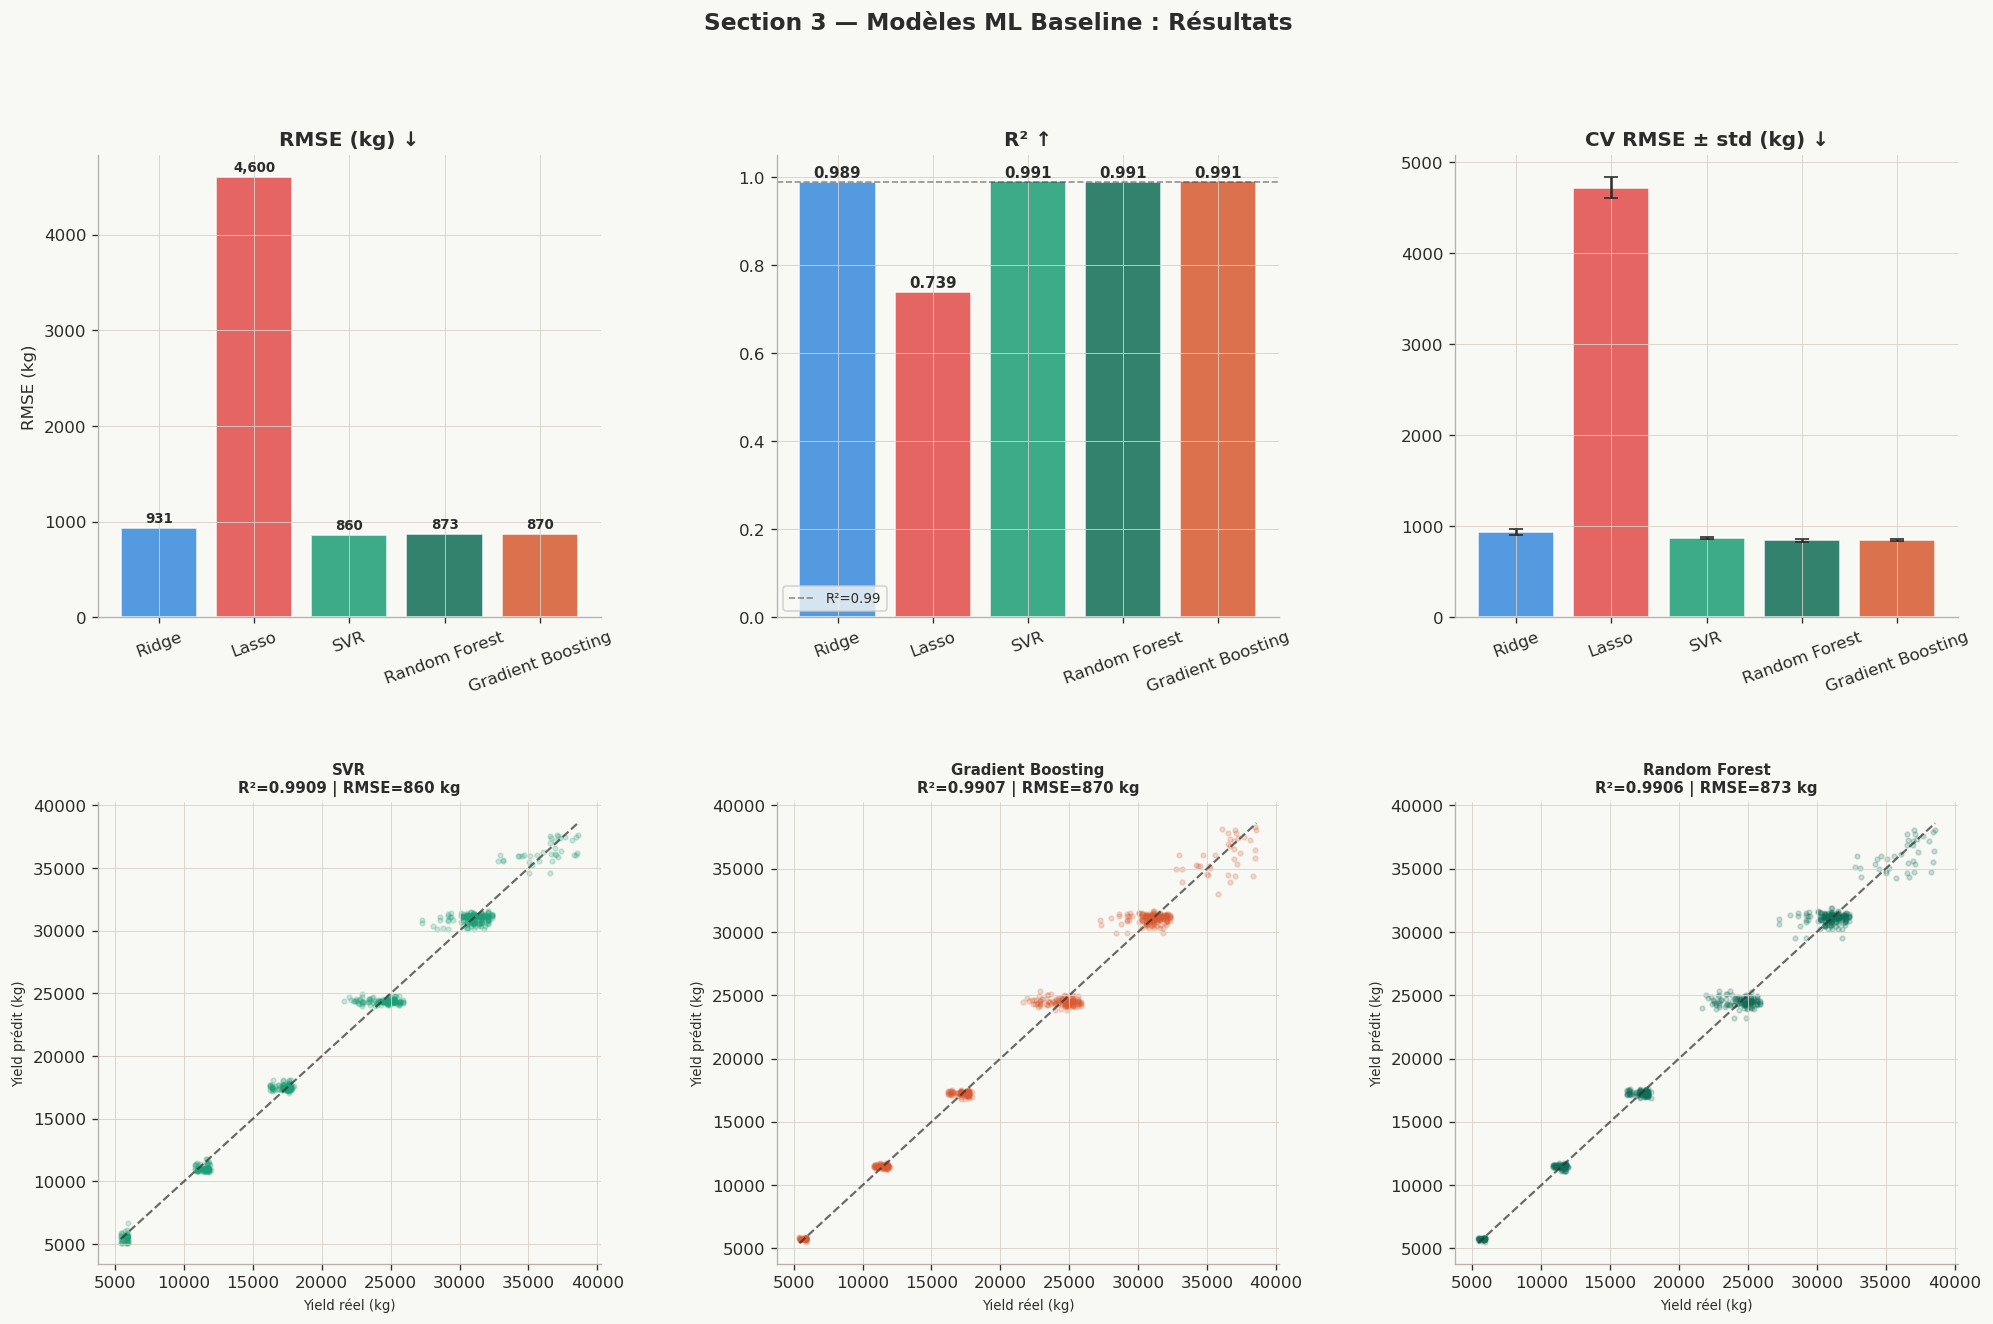

In [67]:
# ─── 3.2 Visualisations ML ────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
fig.suptitle("Section 3 — Modèles ML Baseline : Résultats",
             fontsize=14, fontweight="bold")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

ml_names = list(results_ml.keys())
ml_colors= [results_ml[n]["color"] for n in ml_names]
rmses    = [results_ml[n]["rmse"]  for n in ml_names]
r2s      = [results_ml[n]["r2"]    for n in ml_names]
cvs      = [results_ml[n]["cv_rmse"] for n in ml_names]
cv_stds  = [results_ml[n]["cv_std"]  for n in ml_names]

# RMSE
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(ml_names, rmses, color=ml_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars, rmses):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax1.set_title("RMSE (kg) ↓", fontweight="bold")
ax1.set_ylabel("RMSE (kg)"); ax1.tick_params(axis="x", rotation=20)

# R²
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(ml_names, r2s, color=ml_colors, alpha=0.85, edgecolor="white")
for bar, val in zip(bars2, r2s):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
             f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax2.set_title("R² ↑", fontweight="bold"); ax2.set_ylim(0, 1.05)
ax2.axhline(0.99, color=PALETTE["dark"], ls="--", lw=1, alpha=0.5, label="R²=0.99")
ax2.legend(fontsize=8); ax2.tick_params(axis="x", rotation=20)

# CV RMSE
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(ml_names, cvs, yerr=cv_stds, color=ml_colors, alpha=0.85, edgecolor="white",
        capsize=4, error_kw={"ecolor": PALETTE["dark"], "lw": 1.5})
ax3.set_title("CV RMSE ± std (kg) ↓", fontweight="bold")
ax3.tick_params(axis="x", rotation=20)

# Scatter prédit vs réel — top 3
for i, name in enumerate(sorted(results_ml, key=lambda k: results_ml[k]["r2"],
                                  reverse=True)[:3]):
    ax = fig.add_subplot(gs[1, i])
    y_pred = results_ml[name]["y_pred"]
    ax.scatter(y_test, y_pred, color=results_ml[name]["color"], alpha=0.2, s=8)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn,mx],[mn,mx], color=PALETTE["dark"], lw=1.3, ls="--", alpha=0.7)
    ax.set_title(f"{name}\nR²={results_ml[name]['r2']:.4f} | RMSE={results_ml[name]['rmse']:,.0f} kg",
                 fontweight="bold", fontsize=9)
    ax.set_xlabel("Yield réel (kg)", fontsize=8)
    ax.set_ylabel("Yield prédit (kg)", fontsize=8)

plt.savefig("plot_ml_baseline.png", dpi=120, bbox_inches="tight")
plt.show()


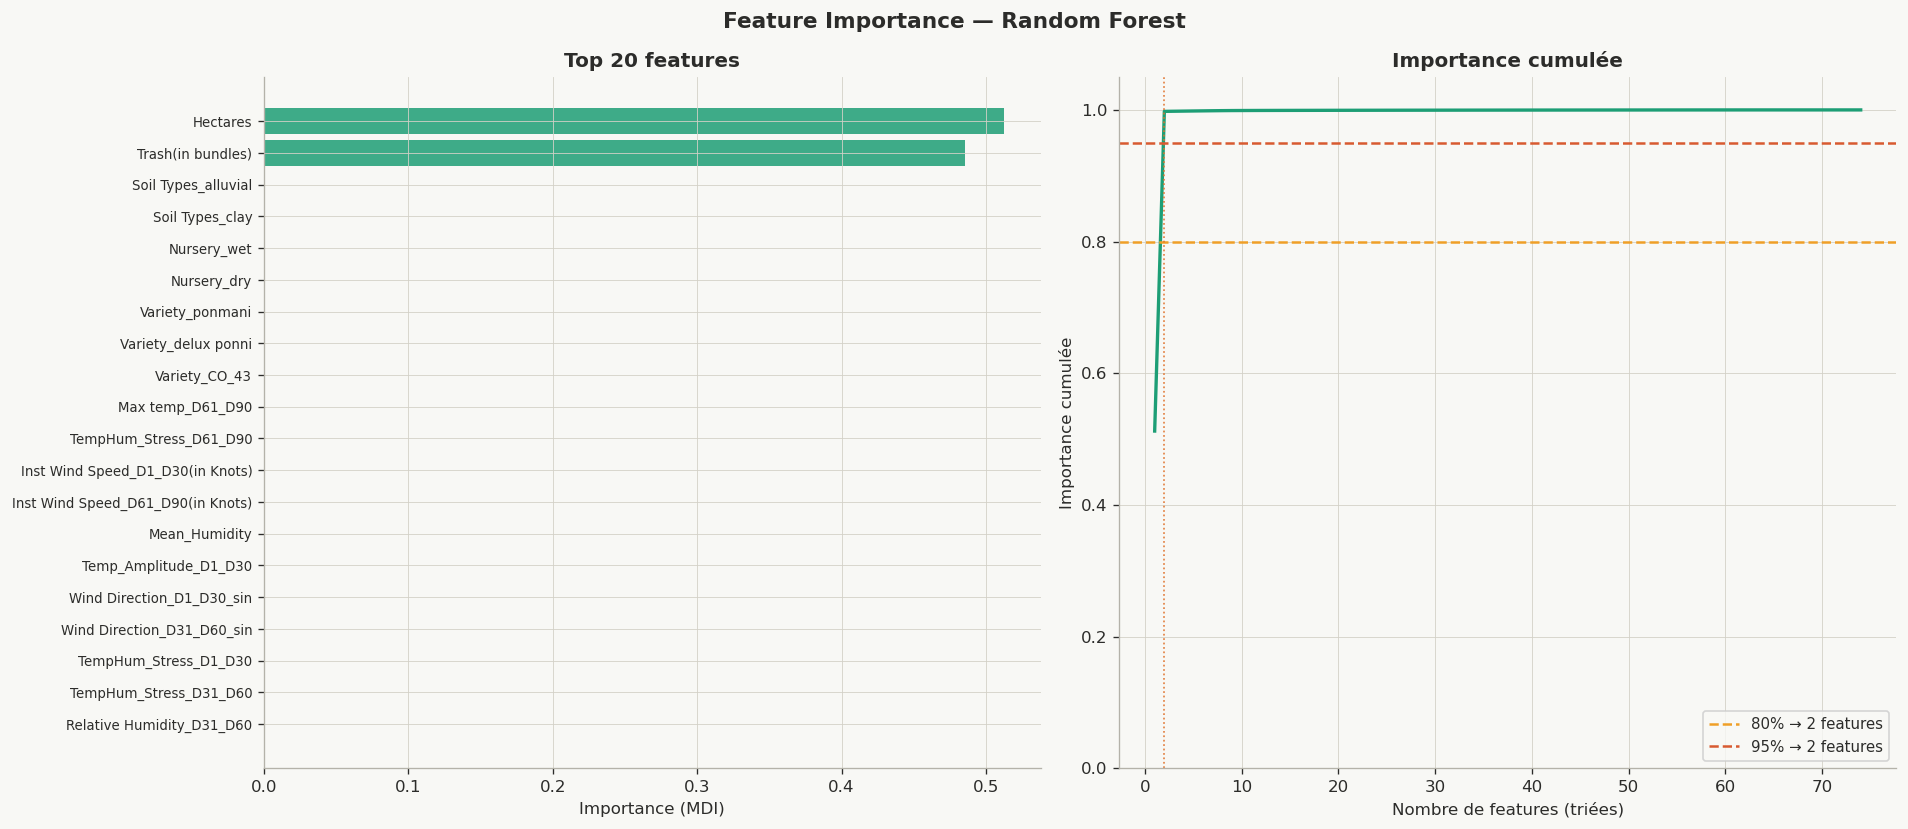

In [68]:
# ─── 3.3 Feature Importance — Random Forest ───────────────────────────────────
rf_model = pickle.load(open(f"{ARTEFACT_DIR}/model_Random_Forest.pkl", "rb"))
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=FEATURE_COLS).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Feature Importance — Random Forest", fontsize=13, fontweight="bold")

# Top 20
top20 = feat_imp.head(20)
colors_imp = [PALETTE["primary"] if i < 5
              else PALETTE["secondary"] if i < 10
              else PALETTE["accent"] for i in range(20)]
axes[0].barh(range(20), top20.values[::-1], color=colors_imp[::-1], alpha=0.85)
axes[0].set_yticks(range(20))
axes[0].set_yticklabels([c[:38] for c in top20.index[::-1]], fontsize=8)
axes[0].set_title("Top 20 features", fontweight="bold")
axes[0].set_xlabel("Importance (MDI)")

# Courbe d'importance cumulée
cumsum = feat_imp.cumsum()
axes[1].plot(range(1, len(cumsum)+1), cumsum.values,
             color=PALETTE["primary"], lw=2)
for thresh, color, label in [(0.80, PALETTE["accent"], "80%"),
                              (0.95, PALETTE["coral"],  "95%")]:
    n = (cumsum < thresh).sum() + 1
    axes[1].axhline(thresh, color=color, ls="--", lw=1.5, label=f"{label} → {n} features")
    axes[1].axvline(n,      color=color, ls=":",  lw=1, alpha=0.6)
axes[1].set_title("Importance cumulée", fontweight="bold")
axes[1].set_xlabel("Nombre de features (triées)"); axes[1].set_ylabel("Importance cumulée")
axes[1].legend(fontsize=9); axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("plot_feature_importance.png", dpi=120, bbox_inches="tight")
plt.show()

# Sauvegarde
with open(f"{ARTEFACT_DIR}/feat_importance_rf.pkl", "wb") as f:
    pickle.dump(feat_imp, f)


---
<a id='4'></a>
## 🔥 Section 4 — Deep Learning : MLP avec TensorFlow / Keras

> TensorFlow permet d'implémenter des architectures bien plus expressives
> que les MLP sklearn grâce aux techniques de régularisation modernes :
>
> | Technique | Rôle |
> |-----------|------|
> | **BatchNormalization** | Normalise les activations → convergence ×2 plus rapide, LR plus élevé possible |
> | **Dropout** | Désactive p% des neurones à chaque forward pass → prévention surapprentissage |
> | **He initialization** | Initialisation optimale pour ReLU → évite vanishing/exploding gradient |
> | **Connexions résiduelles** | `y = x + f(x)` → gradient circule sans disparaître dans les réseaux profonds |
> | **AdamW** | Adam + weight decay → régularisation L2 implicite sur tous les paramètres |

### 3 architectures comparées
- **MLP Standard** : Dense + BatchNorm + ReLU + Dropout × 4 couches
- **MLP Résiduel** : Blocs résiduels style ResNet (connexion identité)
- **MLP Wide** : 5 couches larges (512→512→256→128→64)


In [69]:
# ─── 4.1 Définition des architectures TensorFlow ─────────────────────────────

def build_mlp_standard(n_features):
    """
    MLP Standard : 4 blocs [Dense → BatchNorm → ReLU → Dropout]
    Dropout décroissant (0.30→0.10) : régularisation plus forte sur couches larges.
    kernel_initializer='he_normal' : optimal pour ReLU (évite vanishing gradient).
    """
    inp = keras.Input(shape=(n_features,), name="features")
    x   = inp
    for units, dr in zip([256, 128, 64, 32], [0.30, 0.25, 0.20, 0.10]):
        x = layers.Dense(
                units,
                kernel_initializer="he_normal",
                kernel_regularizer=regularizers.l2(1e-4))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(dr)(x)
    out = layers.Dense(1, name="output")(x)
    return keras.Model(inp, out, name="MLP_Standard")


def residual_block(x, units, dr=0.2):
    """
    Bloc résiduel : chemin principal + connexion identité.
    Si un bloc n'apprend rien d'utile, le réseau met ses poids à ~0
    et laisse passer le signal intact via le shortcut.
    """
    shortcut = x
    # Projection si la dimension change
    if x.shape[-1] != units:
        shortcut = layers.Dense(units, use_bias=False)(x)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Dense(units, kernel_initializer="he_normal",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dr)(x)
    x = layers.Dense(units, kernel_initializer="he_normal",
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])       # ← connexion résiduelle
    return layers.Activation("relu")(x)


def build_mlp_residual(n_features):
    """
    MLP Résiduel : projection initiale → 4 ResBlocks → Dense(1)
    Inspiré de ResNet — permet d'empiler plus de couches sans dégradation.
    """
    inp = keras.Input(shape=(n_features,), name="features")
    x   = layers.Dense(128, kernel_initializer="he_normal")(inp)
    x   = layers.BatchNormalization()(x)
    x   = layers.Activation("relu")(x)
    for units, dr in zip([128, 128, 64, 32], [0.25, 0.20, 0.15, 0.10]):
        x = residual_block(x, units, dr)
    out = layers.Dense(1, name="output")(x)
    return keras.Model(inp, out, name="MLP_Residual")


def build_mlp_wide(n_features):
    """
    MLP Wide : 5 couches larges 512→512→256→128→64
    Plus de capacité pour capturer les 74 interactions features météo × intrants.
    L2 renforcé (5e-4) pour compenser la capacité élevée.
    """
    inp = keras.Input(shape=(n_features,), name="features")
    x   = inp
    for units, dr, l2 in [
        (512, 0.35, 5e-4), (512, 0.30, 5e-4),
        (256, 0.20, 1e-4), (128, 0.15, 1e-4), (64, 0.10, 1e-4)
    ]:
        x = layers.Dense(units, kernel_initializer="he_normal",
                         kernel_regularizer=regularizers.l2(l2))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(dr)(x)
    out = layers.Dense(1, name="output")(x)
    return keras.Model(inp, out, name="MLP_Wide")


# Afficher le résumé des 3 architectures
n_feat = X_train_sc.shape[1]
for builder in [build_mlp_standard, build_mlp_residual, build_mlp_wide]:
    m = builder(n_feat)
    print(f"  {m.name:<16} — {m.count_params():>8,} paramètres")
    m.summary(line_length=80, expand_nested=False)
    print()


  MLP_Standard     —   64,385 paramètres


Model: "MLP_Standard"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)             │ (None, 74)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_64 (Dense)                  │ (None, 256)              │        19,200 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_64            │ (None, 256)              │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_58 (Activation)        │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_43 (Dropout)              │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_65 (Dense)                  │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_65            │ (None, 128)              │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_59 (Activation)        │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_44 (Dropout)              │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_66 (Dense)                  │ (None, 64)               │         8,256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_66            │ (None, 64)               │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_60 (Activation)        │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_45 (Dropout)              │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_67 (Dense)                  │ (None, 32)               │         2,080 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_67            │ (None, 32)               │           128 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_61 (Activation)        │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_46 (Dropout)              │ (None, 32)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ output (Dense)                    │ (None, 1)                │            33 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 64,385 (251.50 KB)

 Trainable params: 63,425 (247.75 KB)

...

Model: "MLP_Wide"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ features (InputLayer)             │ (None, 74)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_79 (Dense)                  │ (None, 512)              │        38,400 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_79            │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_71 (Activation)        │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_51 (Dropout)              │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_80 (Dense)                  │ (None, 512)              │       262,656 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_80            │ (None, 512)              │         2,048 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_72 (Activation)        │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_52 (Dropout)              │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_81 (Dense)                  │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_81            │ (None, 256)              │         1,024 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_73 (Activation)        │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_53 (Dropout)              │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_82 (Dense)                  │ (None, 128)              │        32,896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_82            │ (None, 128)              │           512 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_74 (Activation)        │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_54 (Dropout)              │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_83 (Dense)                  │ (None, 64)               │         8,256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ batch_normalization_83            │ (None, 64)               │           256 │
│ (BatchNormalization)              │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ activation_75 (Activation)        │ (None, 64)               │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_55 (Dropout)              │ (None, 64)               │             0 │
├──────────────────────────────

 Total params: 479,489 (1.83 MB)

 Trainable params: 476,545 (1.82 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [70]:
# ─── 4.2 Callbacks & entraînement TensorFlow ─────────────────────────────────

def get_callbacks(model_name):
    """
    EarlyStopping    : surveille val_loss, arrête si pas d'amélioration sur 30 epochs.
                       restore_best_weights=True → revient automatiquement au meilleur état.
    ReduceLROnPlateau: divise le LR par 2 si stagnation sur 15 epochs.
                       Permet un fine-tuning progressif sans intervention manuelle.
    ModelCheckpoint  : sauvegarde uniquement le meilleur checkpoint (.keras).
    """
    return [
        callbacks.EarlyStopping(
            monitor              = "val_loss",
            patience             = 30,
            restore_best_weights = True,
            verbose              = 1,
            min_delta            = 1e-5,
        ),
        callbacks.ReduceLROnPlateau(
            monitor   = "val_loss",
            factor    = 0.5,
            patience  = 15,
            min_lr    = 1e-6,
            verbose   = 1,
            min_delta = 1e-5,
        ),
        callbacks.ModelCheckpoint(
            filepath       = f"checkpoints/{model_name}_best.keras",
            monitor        = "val_loss",
            save_best_only = True,
            verbose        = 0,
        ),
    ]


# ─── Split train / validation (85% / 15%) depuis X_train_sc ─────────────────
n_val  = int(len(X_train_sc) * 0.15)
rng    = np.random.default_rng(RANDOM_SEED)
idx    = rng.permutation(len(X_train_sc))
X_fit  = X_train_sc[idx[n_val:]].astype(np.float32)
y_fit  = y_train_sc[idx[n_val:]].astype(np.float32)
X_val  = X_train_sc[idx[:n_val]].astype(np.float32)
y_val  = y_train_sc[idx[:n_val]].astype(np.float32)

print(f"Split entraînement : {len(X_fit)} | validation : {len(X_val)}")

# ─── Entraînement des 3 architectures ────────────────────────────────────────
ARCH_BUILDERS = {
    "MLP_Standard": build_mlp_standard,
    "MLP_Residual": build_mlp_residual,
    "MLP_Wide"    : build_mlp_wide,
}

results_tf = {}

for arch_name, builder in ARCH_BUILDERS.items():
    print(f"\n{'='*60}")
    print(f"▶ {arch_name}")
    print(f"{'='*60}")

    model = builder(X_train_sc.shape[1])

    # AdamW = Adam + weight_decay (régularisation L2 implicite)
    model.compile(
        optimizer = optimizers.Adam(learning_rate=1e-3, weight_decay=1e-5),
        loss      = "mse",
        metrics   = ["mae"],
    )

    t0      = time.time()
    history = model.fit(
        X_fit, y_fit,
        validation_data = (X_val, y_val),
        epochs          = 500,
        batch_size      = 64,
        callbacks       = get_callbacks(arch_name),
        verbose         = 1,
    )
    elapsed = time.time() - t0

    # Prédictions sur test (inversion du scaling)
    y_pred_sc = model.predict(X_test_sc, verbose=0).ravel()
    y_pred    = scaler_y.inverse_transform(y_pred_sc.reshape(-1, 1)).ravel()

    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mae_ = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))

    results_tf[arch_name] = {
        "model"   : model,
        "y_pred"  : y_pred,
        "rmse"    : rmse,
        "mae"     : mae_,
        "r2"      : r2,
        "history" : history.history,
        "n_params": model.count_params(),
        "n_epochs": len(history.history["loss"]),
        "time"    : elapsed,
    }

    model.save(f"saved_models/{arch_name}.keras")

    print(f"\n  ✓ Epochs     : {len(history.history['loss'])}")
    print(f"  ✓ RMSE (kg)  : {rmse:,.1f}")
    print(f"  ✓ MAE  (kg)  : {mae_:,.1f}")
    print(f"  ✓ R²         : {r2:.4f}")
    print(f"  ✓ Temps      : {elapsed:.1f}s")

# Résumé
print("\n" + "="*60)
print(f"{'Modèle':<18} {'Params':>10} {'RMSE (kg)':>10} {'R²':>8} {'Epochs':>7}")
print("-"*55)
for n, r in sorted(results_tf.items(), key=lambda x: x[1]["r2"], reverse=True):
    print(f"  {n:<16} {r['n_params']:>10,} {r['rmse']:>10,.1f} {r['r2']:>8.4f} {r['n_epochs']:>7}")


Split entraînement : 1897 | validation : 334

▶ MLP_Standard
Epoch 1/500


E0000 00:00:1774190367.451712 16769634 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.3524 - mae: 0.9108 - val_loss: 1.0786 - val_mae: 0.8564 - learning_rate: 0.0010
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7115 - mae: 0.6283 - val_loss: 0.5482 - val_mae: 0.5345 - learning_rate: 0.0010
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5600 - mae: 0.5426 - val_loss: 0.2224 - val_mae: 0.2783 - learning_rate: 0.0010
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4601 - mae: 0.4844 - val_loss: 0.1790 - val_mae: 0.2379 - learning_rate: 0.0010
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3973 - mae: 0.4384 - val_loss: 0.1557 - val_mae: 0.2025 - learning_rate: 0.0010
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3928 - mae: 0.4360 - val_loss: 0.1396 - val_mae: 0.1793 - learning_rate: 0.0010
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.3523 - mae: 0.4048 - val_loss: 0.1479 - val_mae: 0.1912 - learning_rate: 0.0010
Epoch 8/500
30/30 ━━━━━━

E0000 00:00:1774190431.044964 16769634 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Epochs     : 375
  ✓ RMSE (kg)  : 875.6
  ✓ MAE  (kg)  : 631.1
  ✓ R²         : 0.9905
  ✓ Temps      : 63.6s

▶ MLP_Residual
Epoch 1/500
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.6272 - mae: 0.9592 

...


  ✓ Epochs     : 493
  ✓ RMSE (kg)  : 942.5
  ✓ MAE  (kg)  : 672.6
  ✓ R²         : 0.9890
  ✓ Temps      : 117.1s

▶ MLP_Wide
Epoch 1/500
23/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.7614 - mae: 1.0183

E0000 00:00:1774190554.795728 16769634 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 2.1755 - mae: 0.8074 - val_loss: 1.5916 - val_mae: 0.5751 - learning_rate: 0.0010
Epoch 2/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.6348 - mae: 0.5829 - val_loss: 1.3557 - val_mae: 0.3928 - learning_rate: 0.0010
Epoch 3/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4650 - mae: 0.4983 - val_loss: 1.2083 - val_mae: 0.3140 - learning_rate: 0.0010
Epoch 4/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.3911 - mae: 0.4592 - val_loss: 1.1248 - val_mae: 0.2110 - learning_rate: 0.0010
Epoch 5/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.3273 - mae: 0.4163 - val_loss: 1.1197 - val_mae: 0.2275 - learning_rate: 0.0010
Epoch 6/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 1.2844 - mae: 0.3994 - val_loss: 1.0901 - val_mae: 0.2108 - learning_rate: 0.0010
Epoch 7/500
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.2580 - mae: 0.3903 - val_loss: 1.0557 - val_mae: 0.1699 - learning_rate: 0.0010
Epoch 8/500
30/30 ━━

E0000 00:00:1774190739.684304 16769634 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}



  ✓ Epochs     : 500
  ✓ RMSE (kg)  : 864.3
  ✓ MAE  (kg)  : 603.8
  ✓ R²         : 0.9908
  ✓ Temps      : 190.3s

Modèle                 Params  RMSE (kg)       R²  Epochs
-------------------------------------------------------
  MLP_Wide            479,489      864.3   0.9908     500
  MLP_Standard         64,385      875.6   0.9905     375
  MLP_Residual        105,185      942.5   0.9890     493


---
<a id='5'></a>
## 📈 Section 5 — Visualisations Deep Learning TensorFlow


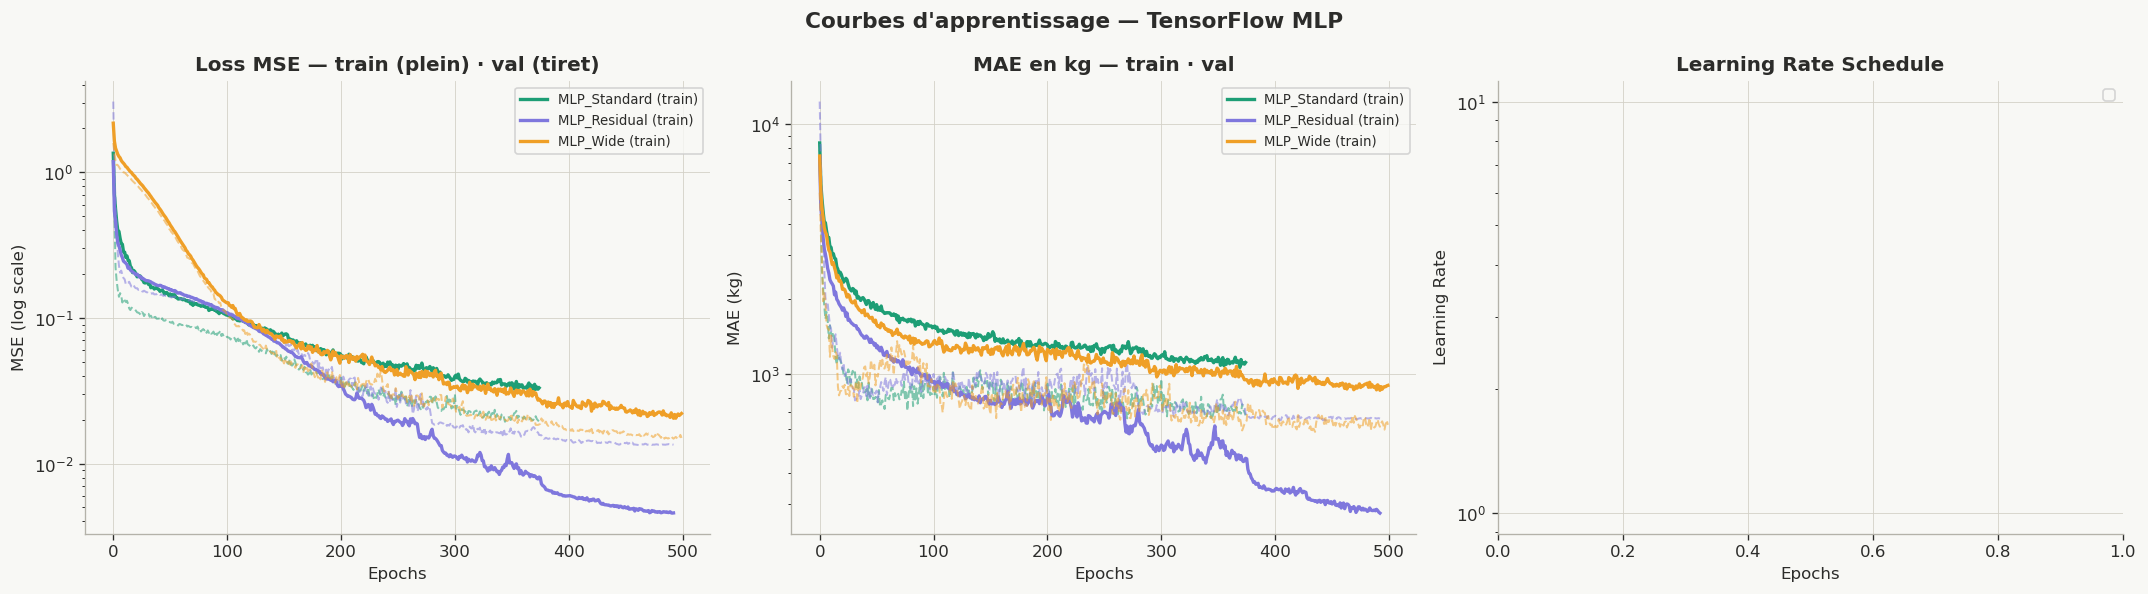

In [71]:
# ─── 5.1 Courbes d'apprentissage — train & validation ────────────────────────
COLORS_TF = {
    "MLP_Standard": PALETTE["primary"],
    "MLP_Residual": PALETTE["secondary"],
    "MLP_Wide"    : PALETTE["accent"],
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Courbes d'apprentissage — TensorFlow MLP", fontsize=13, fontweight="bold")

for name, r in results_tf.items():
    h = r["history"]
    c = COLORS_TF[name]
    axes[0].plot(h["loss"],     color=c, lw=2,   label=f"{name} (train)")
    axes[0].plot(h["val_loss"], color=c, lw=1.2, ls="--", alpha=0.55)
    axes[1].plot(np.array(h["mae"]) * scaler_y.scale_[0],
                 color=c, lw=2, label=f"{name} (train)")
    axes[1].plot(np.array(h["val_mae"]) * scaler_y.scale_[0],
                 color=c, lw=1.2, ls="--", alpha=0.55)

for ax, title, ylabel in zip(
    axes[:2],
    ["Loss MSE — train (plein) · val (tiret)", "MAE en kg — train · val"],
    ["MSE (log scale)", "MAE (kg)"]
):
    ax.set_yscale("log"); ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epochs"); ax.set_ylabel(ylabel); ax.legend(fontsize=8)

# Learning rate schedule
for name, r in results_tf.items():
    h = r["history"]
    if "lr" in h:
        axes[2].plot(h["lr"], color=COLORS_TF[name], lw=2, label=name)
axes[2].set_title("Learning Rate Schedule", fontweight="bold")
axes[2].set_xlabel("Epochs"); axes[2].set_ylabel("Learning Rate")
axes[2].set_yscale("log"); axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig("plot_tf_learning_curves.png", dpi=120, bbox_inches="tight")
plt.show()


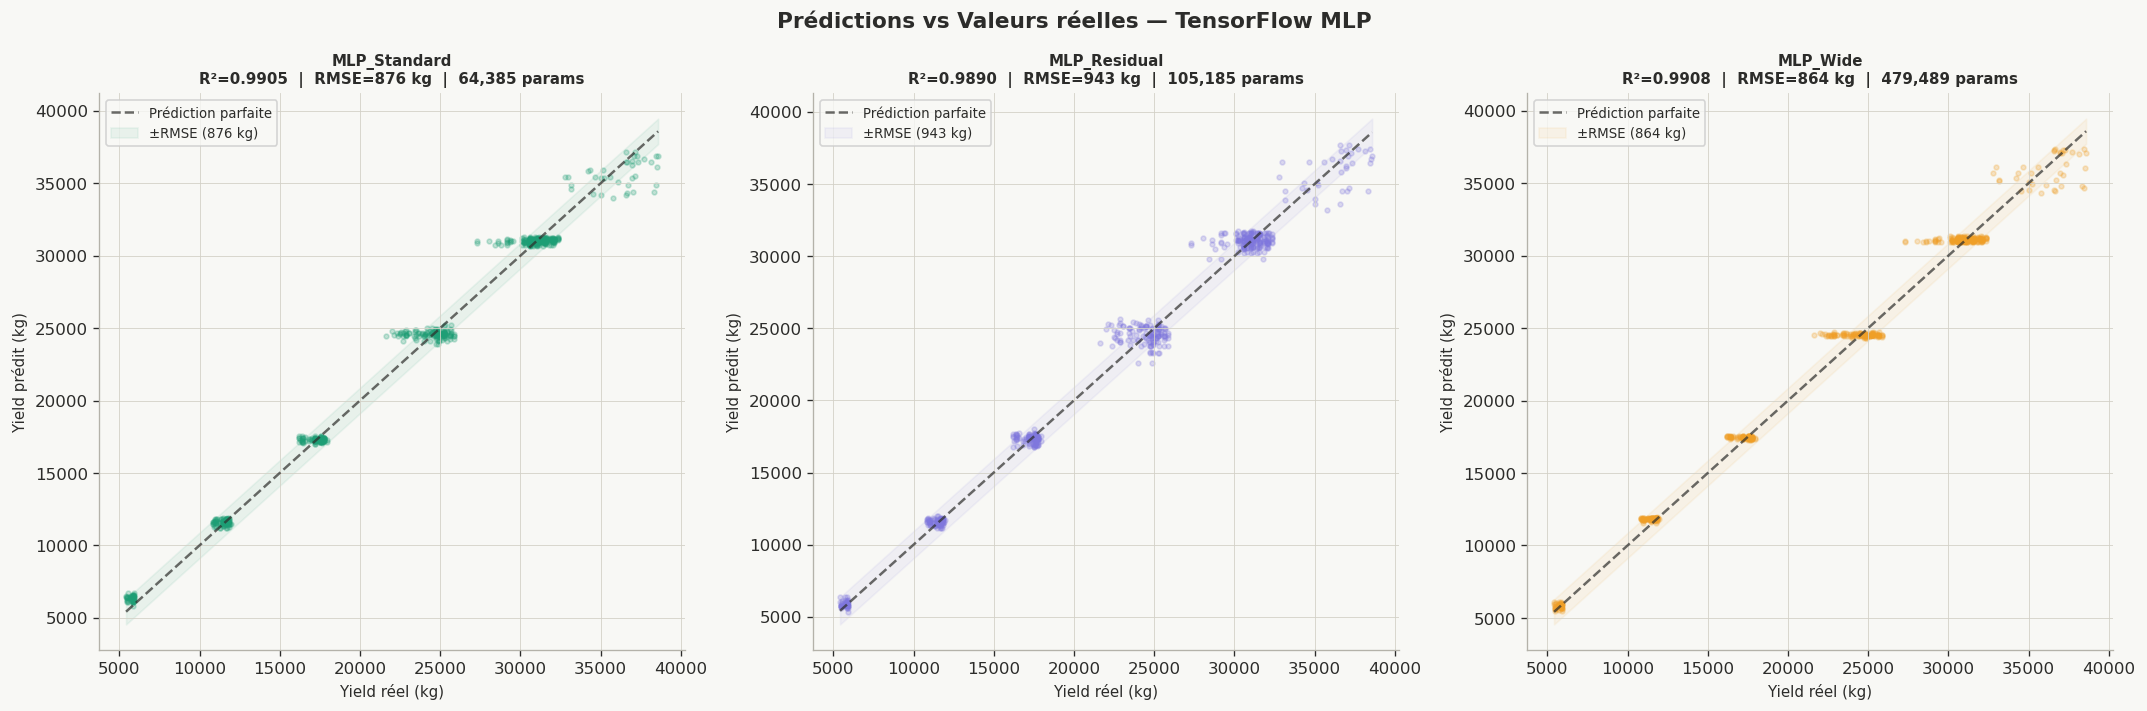

In [72]:
# ─── 5.2 Scatter Prédit vs Réel — 3 architectures TF ─────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Prédictions vs Valeurs réelles — TensorFlow MLP",
             fontsize=13, fontweight="bold")

for ax, (name, r) in zip(axes, results_tf.items()):
    c = COLORS_TF[name]
    ax.scatter(y_test, r["y_pred"], color=c, alpha=0.25, s=8)
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], color=PALETTE["dark"], lw=1.5, ls="--", alpha=0.7,
            label="Prédiction parfaite")

    # Bandes d'erreur ±RMSE
    ax.fill_between([mn, mx], [mn - r["rmse"], mx - r["rmse"]],
                               [mn + r["rmse"], mx + r["rmse"]],
                    color=c, alpha=0.07, label=f"±RMSE ({r['rmse']:,.0f} kg)")

    ax.set_title(f"{name}\nR²={r['r2']:.4f}  |  RMSE={r['rmse']:,.0f} kg  |  "
                 f"{r['n_params']:,} params", fontweight="bold", fontsize=9)
    ax.set_xlabel("Yield réel (kg)", fontsize=9)
    ax.set_ylabel("Yield prédit (kg)", fontsize=9)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_tf_scatter.png", dpi=120, bbox_inches="tight")
plt.show()


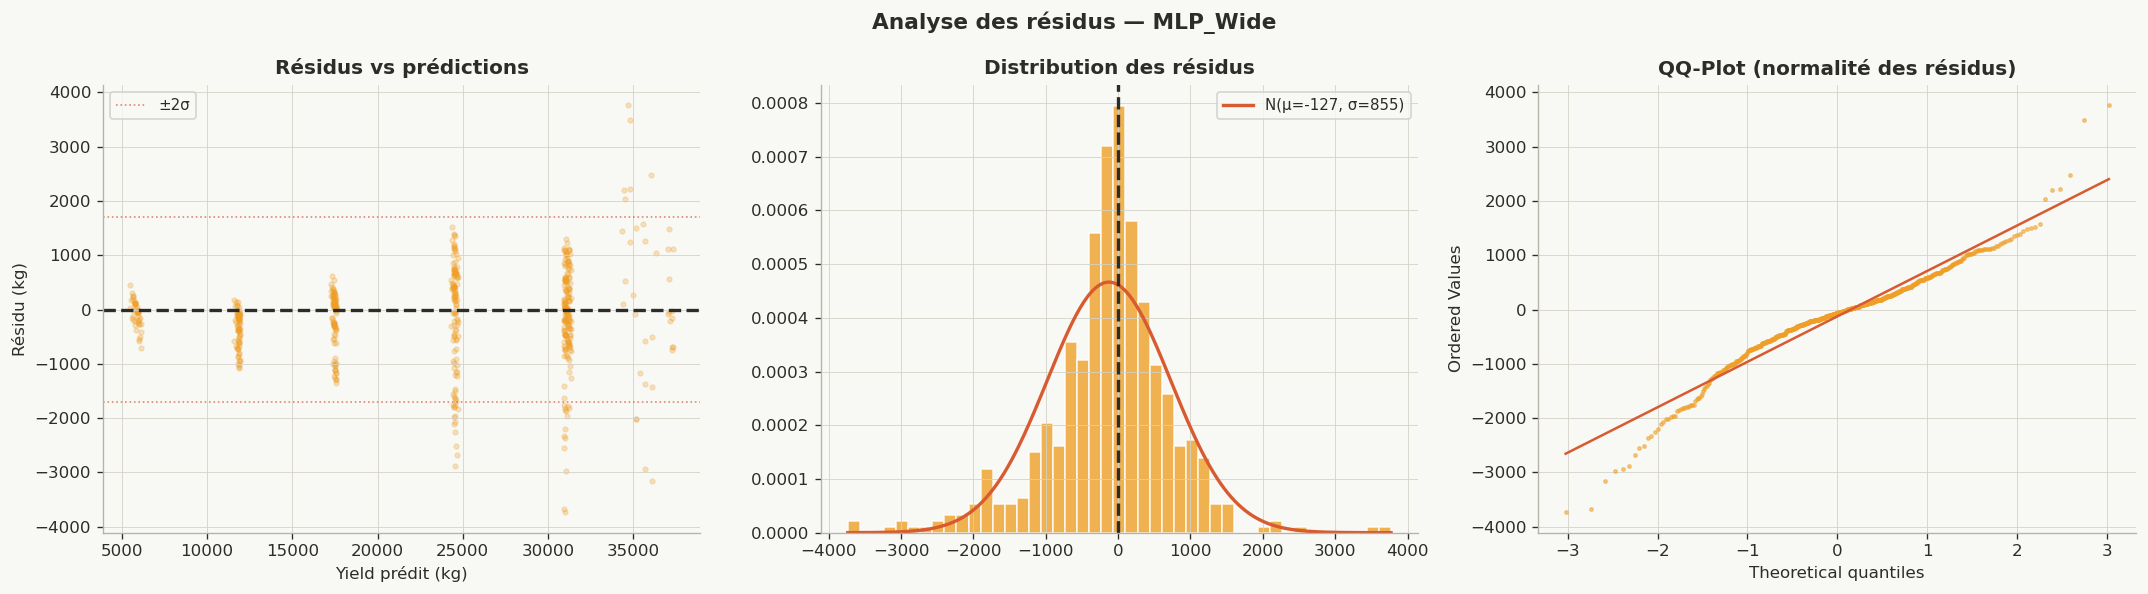

  μ résidus = -126.54 kg  (idéal : 0)
  σ résidus = 854.99 kg
  % dans ±2σ = 93.4%  (idéal : ~95%)


In [73]:
# ─── 5.3 Analyse des résidus — meilleur modèle TF ────────────────────────────
best_tf   = max(results_tf, key=lambda k: results_tf[k]["r2"])
residuals = y_test - results_tf[best_tf]["y_pred"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Analyse des résidus — {best_tf}", fontsize=13, fontweight="bold")

c = COLORS_TF[best_tf]

# Résidus vs prédictions
axes[0].scatter(results_tf[best_tf]["y_pred"], residuals, color=c, alpha=0.25, s=8)
axes[0].axhline(0,  color=PALETTE["dark"],  lw=2, ls="--")
axes[0].axhline( 2*residuals.std(), color=PALETTE["coral"], lw=1, ls=":", alpha=0.7,
                label="±2σ")
axes[0].axhline(-2*residuals.std(), color=PALETTE["coral"], lw=1, ls=":", alpha=0.7)
axes[0].set_xlabel("Yield prédit (kg)"); axes[0].set_ylabel("Résidu (kg)")
axes[0].set_title("Résidus vs prédictions", fontweight="bold"); axes[0].legend(fontsize=9)

# Distribution + courbe normale théorique
axes[1].hist(residuals, bins=45, color=c, alpha=0.8, edgecolor="white", density=True)
xn = np.linspace(residuals.min(), residuals.max(), 300)
axes[1].plot(xn, stats.norm.pdf(xn, residuals.mean(), residuals.std()),
             color=PALETTE["coral"], lw=2, label=f"N(μ={residuals.mean():.0f}, σ={residuals.std():.0f})")
axes[1].axvline(0, color=PALETTE["dark"], lw=2, ls="--")
axes[1].set_title("Distribution des résidus", fontweight="bold"); axes[1].legend(fontsize=9)

# QQ-plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("QQ-Plot (normalité des résidus)", fontweight="bold")
axes[2].get_lines()[0].set(color=c, markersize=2, alpha=0.5)
axes[2].get_lines()[1].set(color=PALETTE["coral"], lw=1.5)

plt.tight_layout()
plt.savefig("plot_tf_residuals.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"  μ résidus = {residuals.mean():.2f} kg  (idéal : 0)")
print(f"  σ résidus = {residuals.std():.2f} kg")
print(f"  % dans ±2σ = {(abs(residuals) < 2*residuals.std()).mean():.1%}  (idéal : ~95%)")


---
<a id='6'></a>
## 🏆 Section 6 — Comparaison Finale ML vs Deep Learning

> Dashboard de synthèse : tous les modèles côte à côte sur les mêmes métriques.


In [74]:
# ─── 6.1 Tableau de synthèse — tous modèles ──────────────────────────────────
all_results = {}

for name, r in results_ml.items():
    all_results[name] = {**r, "type": "ML"}

for name, r in results_tf.items():
    all_results[name] = {
        "rmse": r["rmse"], "mae": r["mae"], "r2": r["r2"],
        "cv_rmse": r["rmse"],    # pas de CV pour TF (coûteux), on utilise test RMSE
        "cv_std": 0.0,
        "time": r["time"],
        "type": "Deep Learning (TF)",
        "color": MODEL_COLORS.get(name, PALETTE["secondary"]),
    }

summary_df = pd.DataFrame([
    {
        "Modèle"    : k,
        "Type"      : v["type"],
        "RMSE (kg)" : round(v["rmse"], 1),
        "MAE (kg)"  : round(v["mae"],  1),
        "R²"        : round(v["r2"],   4),
    }
    for k, v in all_results.items()
]).sort_values("R²", ascending=False).reset_index(drop=True)

summary_df.index += 1
print(summary_df.to_string())

best = summary_df.iloc[0]
print(f"\n★ Champion global : {best['Modèle']}  |  R²={best['R²']}  |  RMSE={best['RMSE (kg)']:,.1f} kg")


              Modèle                Type  RMSE (kg)  MAE (kg)      R²
1                SVR                  ML      860.2     650.9  0.9909
2           MLP_Wide  Deep Learning (TF)      864.3     603.8  0.9908
3  Gradient Boosting                  ML      870.3     616.5  0.9907
4      Random Forest                  ML      872.9     621.0  0.9906
5       MLP_Standard  Deep Learning (TF)      875.6     631.1  0.9905
6              Ridge                  ML      930.6     699.9  0.9893
7       MLP_Residual  Deep Learning (TF)      942.5     672.6  0.9890
8              Lasso                  ML     4599.6    4071.1  0.7392

★ Champion global : SVR  |  R²=0.9909  |  RMSE=860.2 kg


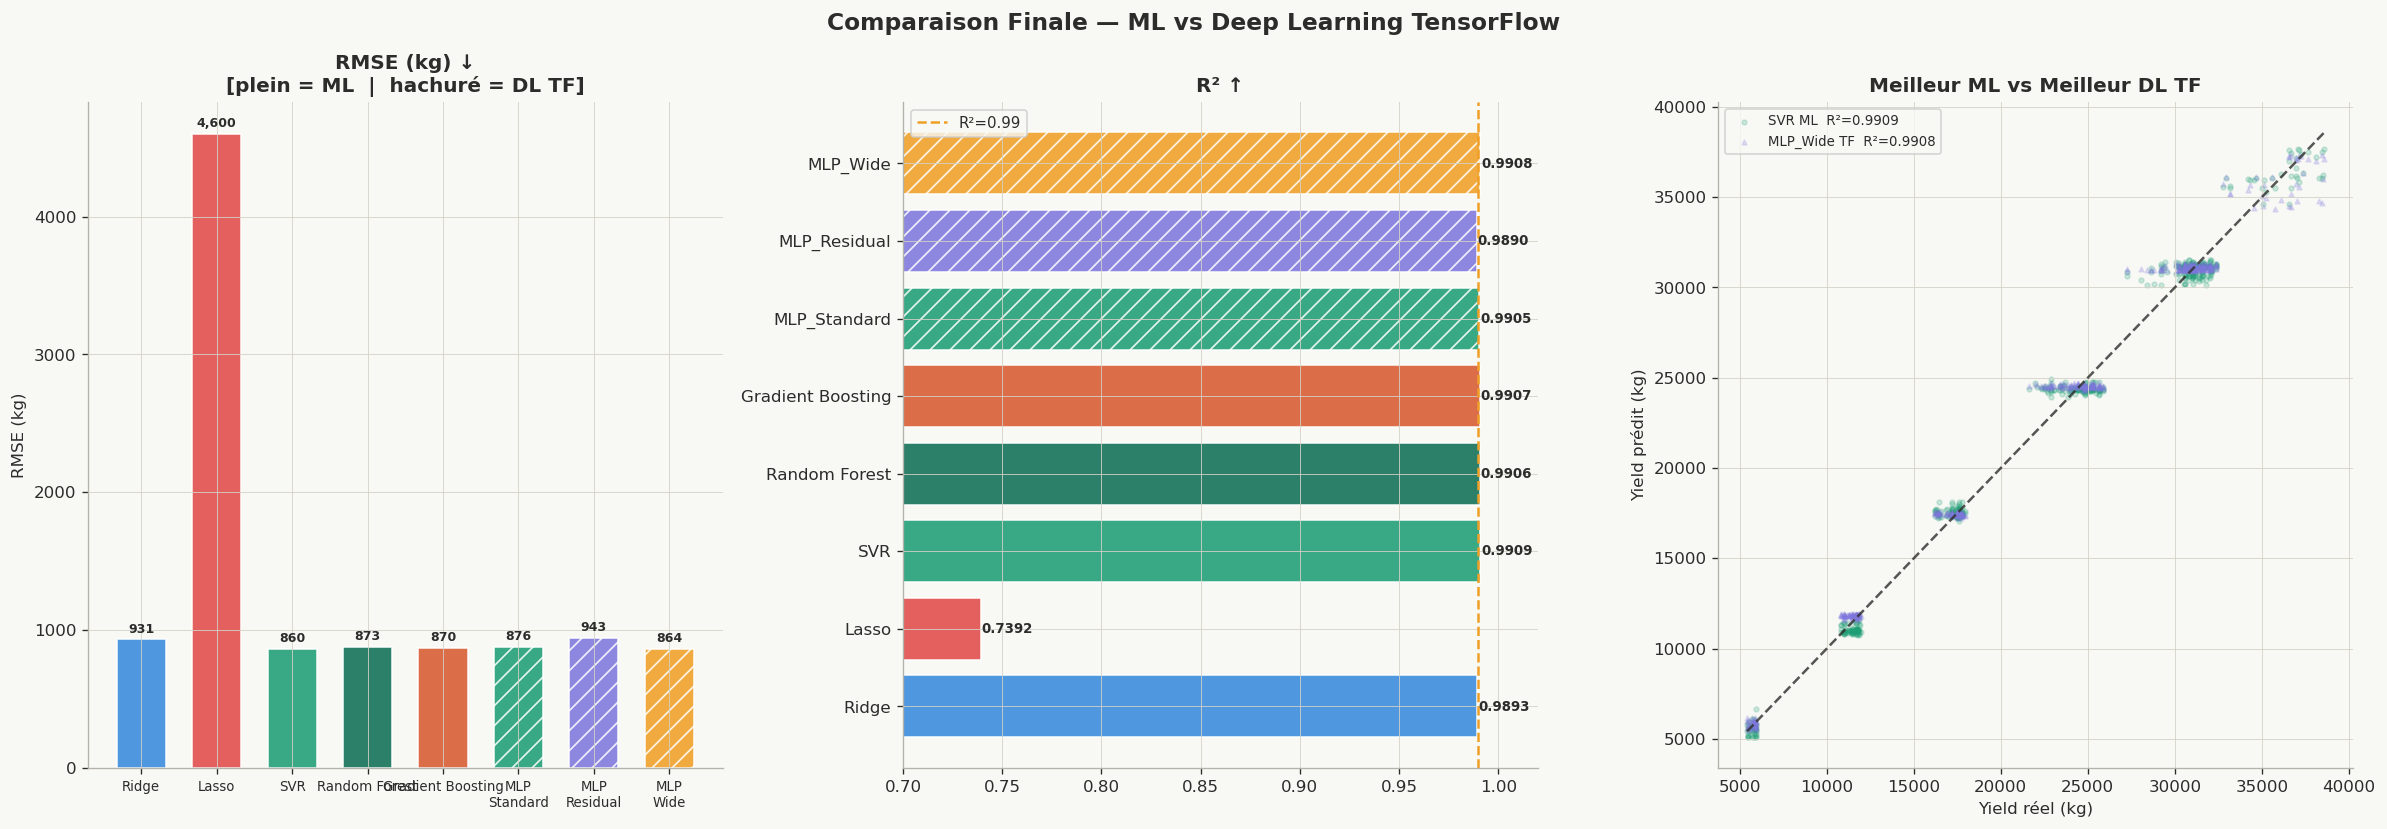

In [75]:
# ─── 6.2 Dashboard comparatif final ML vs Deep Learning TF ───────────────────
names_all  = list(all_results.keys())
colors_all = [all_results[n].get("color", PALETTE["gray"]) for n in names_all]
rmses_all  = [all_results[n]["rmse"] for n in names_all]
r2s_all    = [all_results[n]["r2"]   for n in names_all]
types_all  = [all_results[n]["type"] for n in names_all]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle("Comparaison Finale — ML vs Deep Learning TensorFlow",
             fontsize=14, fontweight="bold")

x = np.arange(len(names_all))
w = 0.65

# RMSE
bars = axes[0].bar(x, rmses_all, w, color=colors_all, alpha=0.88, edgecolor="white")
for bar, t in zip(bars, types_all):
    if "TF" in t or "Deep" in t:
        bar.set_hatch("//"); bar.set_edgecolor("white")
    axes[0].text(bar.get_x()+w/2, bar.get_height()+30,
                 f"{bar.get_height():,.0f}", ha="center", va="bottom",
                 fontsize=7.5, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels([n.replace("_", "\n") for n in names_all], fontsize=8)
axes[0].set_title("RMSE (kg) ↓\n[plein = ML  |  hachuré = DL TF]", fontweight="bold")
axes[0].set_ylabel("RMSE (kg)")

# R²
bars2 = axes[1].barh(names_all, r2s_all, color=colors_all, alpha=0.88, edgecolor="white")
for bar, t, val in zip(bars2, types_all, r2s_all):
    if "TF" in t or "Deep" in t:
        bar.set_hatch("//"); bar.set_edgecolor("white")
    axes[1].text(val + 0.0005, bar.get_y()+bar.get_height()/2,
                 f"{val:.4f}", va="center", fontsize=8, fontweight="bold")
axes[1].axvline(0.99, color=PALETTE["accent"], ls="--", lw=1.5, label="R²=0.99")
axes[1].set_xlim(0.70, 1.02)
axes[1].set_title("R² ↑", fontweight="bold"); axes[1].legend(fontsize=9)

# Scatter meilleur ML vs meilleur DL TF
best_ml_name = max(results_ml, key=lambda k: results_ml[k]["r2"])
best_tf_name = max(results_tf, key=lambda k: results_tf[k]["r2"])
axes[2].scatter(y_test, results_ml[best_ml_name]["y_pred"],
                color=PALETTE["primary"], alpha=0.20, s=8,
                label=f"{best_ml_name} ML  R²={results_ml[best_ml_name]['r2']:.4f}")
axes[2].scatter(y_test, results_tf[best_tf_name]["y_pred"],
                color=PALETTE["secondary"], alpha=0.20, s=8, marker="^",
                label=f"{best_tf_name} TF  R²={results_tf[best_tf_name]['r2']:.4f}")
mn, mx = y_test.min(), y_test.max()
axes[2].plot([mn, mx], [mn, mx], color=PALETTE["dark"], lw=1.5, ls="--", alpha=0.8)
axes[2].set_title("Meilleur ML vs Meilleur DL TF", fontweight="bold")
axes[2].set_xlabel("Yield réel (kg)"); axes[2].set_ylabel("Yield prédit (kg)")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_final_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


---
<a id='7'></a>
## 🔍 Section 7 — Interprétabilité & Analyse des Résidus

> Un bon modèle ne suffit pas — il faut pouvoir **expliquer** ses prédictions.
> L'analyse des résidus révèle si le modèle fait des erreurs systématiques.


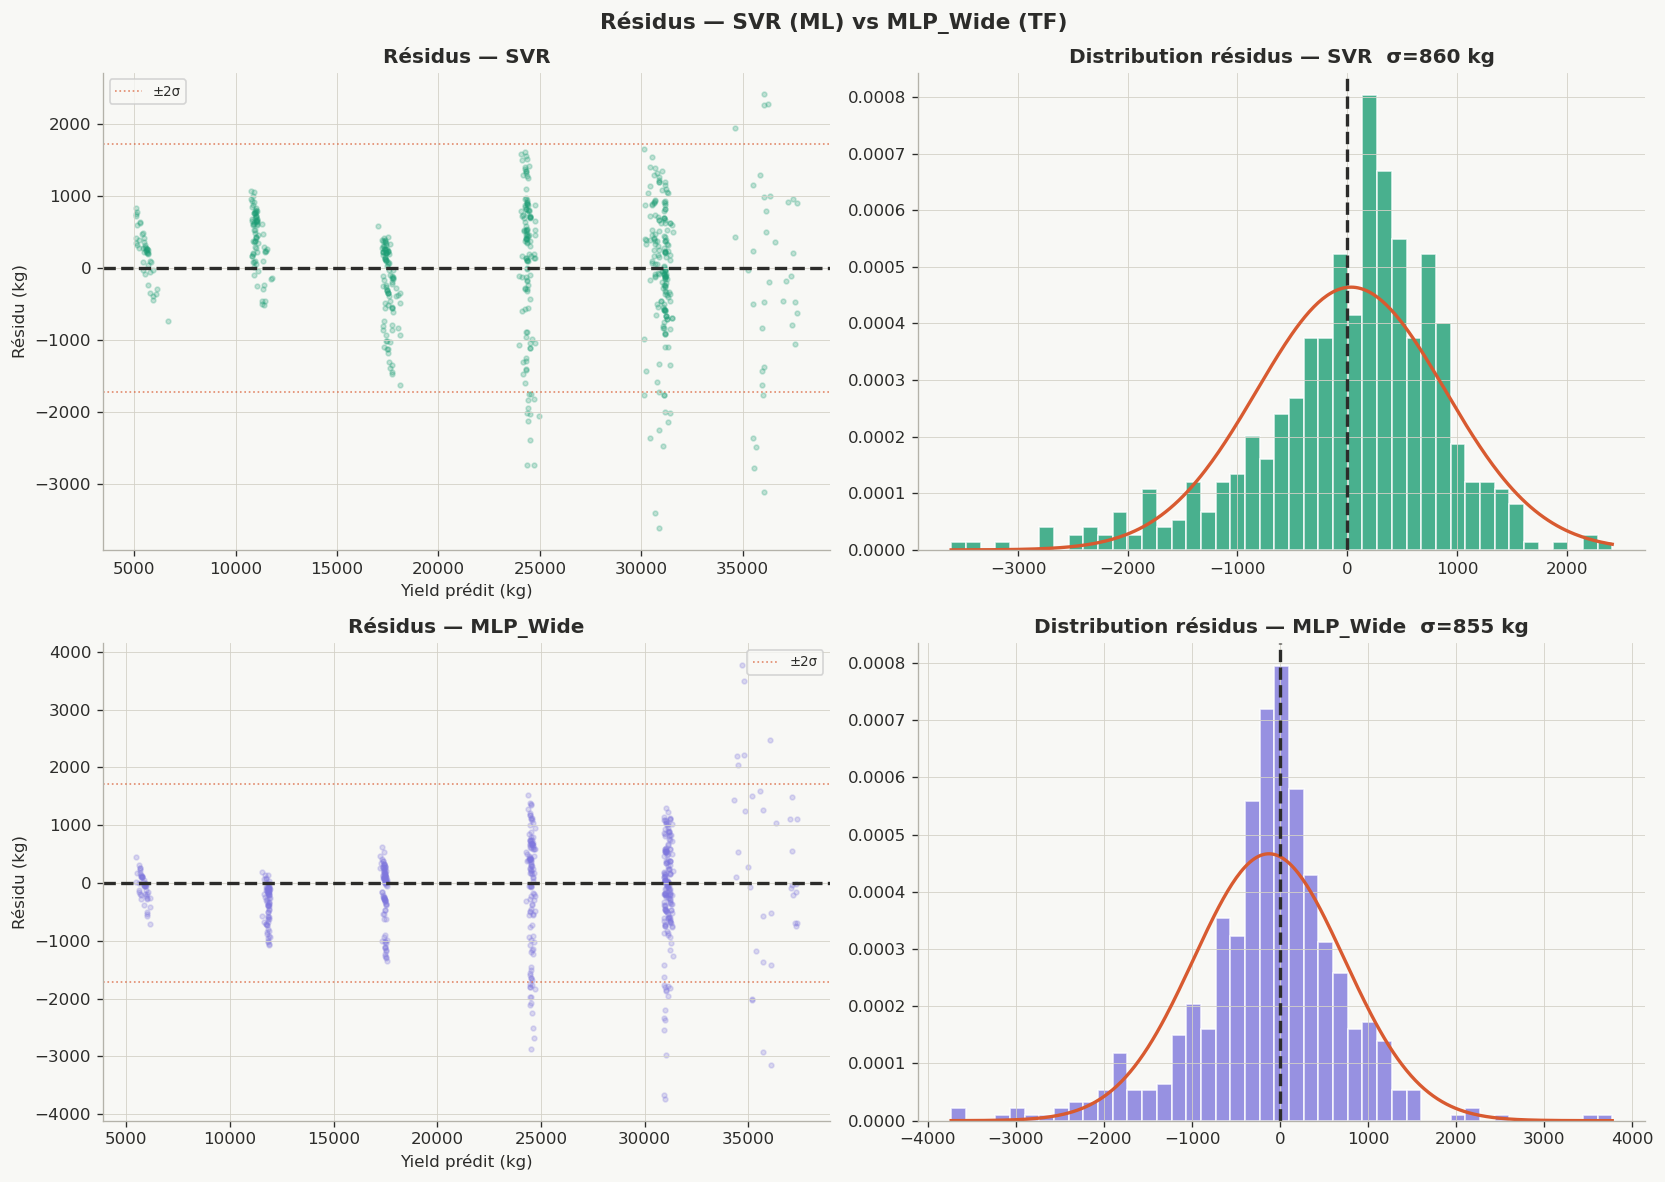

In [76]:
# ─── 7.1 Analyse des résidus — meilleur modèle global ────────────────────────
# On compare les résidus du meilleur ML et du meilleur DL TF côte à côte.

best_ml_name = max(results_ml, key=lambda k: results_ml[k]["r2"])
best_tf_name = max(results_tf, key=lambda k: results_tf[k]["r2"])

res_ml = y_test - results_ml[best_ml_name]["y_pred"]
res_tf = y_test - results_tf[best_tf_name]["y_pred"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Résidus — {best_ml_name} (ML) vs {best_tf_name} (TF)",
             fontsize=13, fontweight="bold")

for ax_row, (res, name, color) in enumerate([
    (res_ml, best_ml_name, PALETTE["primary"]),
    (res_tf, best_tf_name, PALETTE["secondary"]),
]):
    # Résidus vs prédictions
    y_pred_used = (results_ml[name]["y_pred"] if name in results_ml
                   else results_tf[name]["y_pred"])
    axes[ax_row, 0].scatter(y_pred_used, res, color=color, alpha=0.25, s=8)
    axes[ax_row, 0].axhline(0, color=PALETTE["dark"], lw=2, ls="--")
    axes[ax_row, 0].axhline( 2*res.std(), color=PALETTE["coral"], lw=1, ls=":", alpha=0.7, label="±2σ")
    axes[ax_row, 0].axhline(-2*res.std(), color=PALETTE["coral"], lw=1, ls=":", alpha=0.7)
    axes[ax_row, 0].set_title(f"Résidus — {name}", fontweight="bold")
    axes[ax_row, 0].set_xlabel("Yield prédit (kg)"); axes[ax_row, 0].set_ylabel("Résidu (kg)")
    axes[ax_row, 0].legend(fontsize=8)

    # Distribution + normale théorique
    axes[ax_row, 1].hist(res, bins=45, color=color, alpha=0.8, edgecolor="white", density=True)
    xn = np.linspace(res.min(), res.max(), 300)
    axes[ax_row, 1].plot(xn, stats.norm.pdf(xn, res.mean(), res.std()),
                         color=PALETTE["coral"], lw=2)
    axes[ax_row, 1].axvline(0, color=PALETTE["dark"], lw=2, ls="--")
    axes[ax_row, 1].set_title(f"Distribution résidus — {name}  σ={res.std():.0f} kg",
                               fontweight="bold")

plt.tight_layout()
plt.savefig("plot_residuals_comparison.png", dpi=120, bbox_inches="tight")
plt.show()


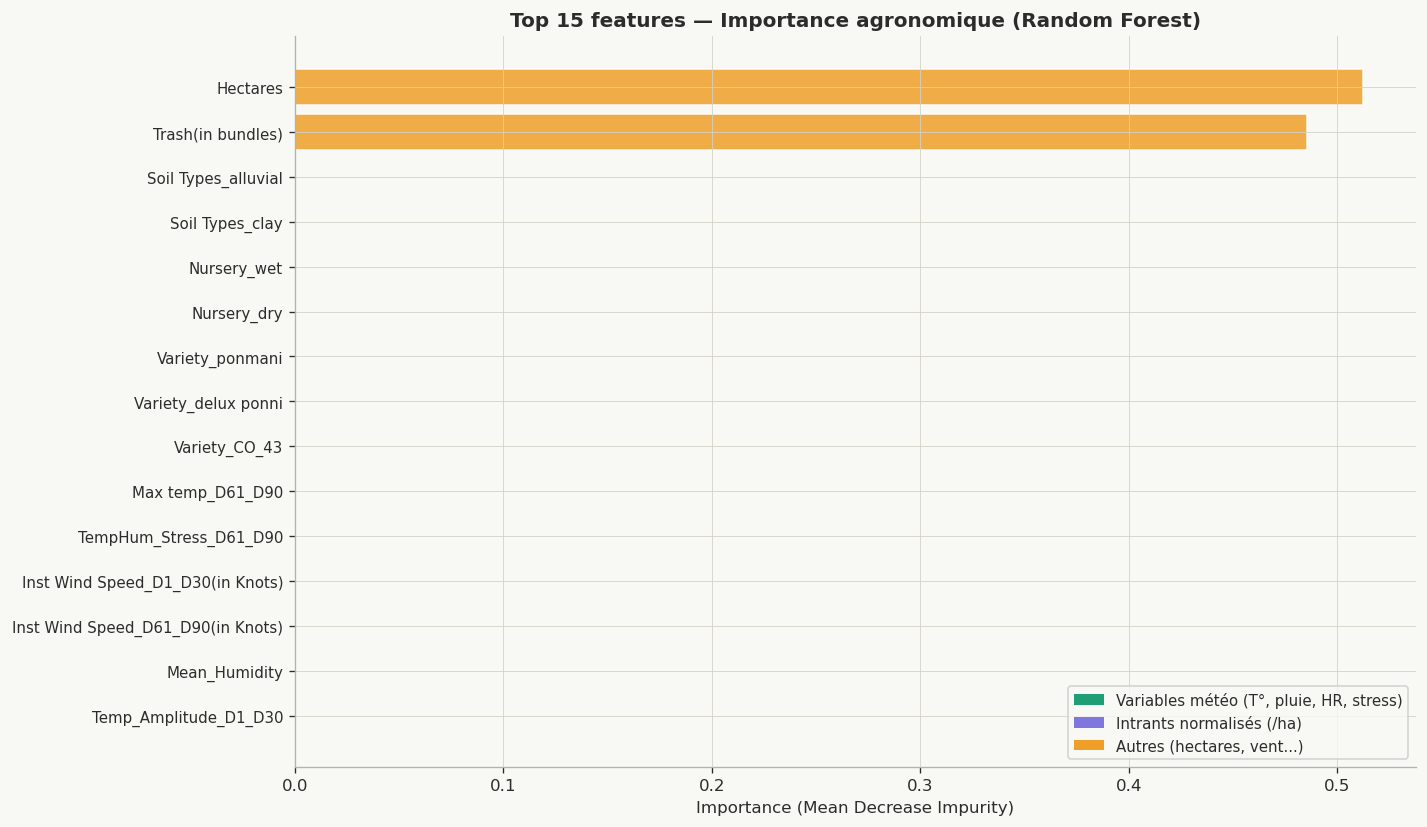

In [77]:
# ─── 7.2 Top features & interprétation agronomique ───────────────────────────
feat_imp = pickle.load(open(f"{ARTEFACT_DIR}/feat_importance_rf.pkl","rb"))
top15    = feat_imp.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

colors_imp = [PALETTE["primary"] if "temp" in c.lower() or "rain" in c.lower()
              or "humidity" in c.lower() or "stress" in c.lower()
              else PALETTE["secondary"] if "_per_ha" in c
              else PALETTE["accent"]
              for c in top15.index]

bars = ax.barh(range(len(top15)), top15.values[::-1],
               color=colors_imp[::-1], alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([c[:45] for c in top15.index[::-1]], fontsize=9)
ax.set_title("Top 15 features — Importance agronomique (Random Forest)",
             fontweight="bold", fontsize=12)
ax.set_xlabel("Importance (Mean Decrease Impurity)")

# Légende des couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE["primary"],   label="Variables météo (T°, pluie, HR, stress)"),
    Patch(facecolor=PALETTE["secondary"], label="Intrants normalisés (/ha)"),
    Patch(facecolor=PALETTE["accent"],    label="Autres (hectares, vent...)"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="lower right")

plt.tight_layout()
plt.savefig("plot_feature_importance_final.png", dpi=120, bbox_inches="tight")
plt.show()


---
<a id='8'></a>
## 🚀 Section 8 — Inférence : Prédiction sur nouvelles données

> Pipeline complet pour prédire le rendement d'une nouvelle parcelle.


In [78]:
# ─── 8.1 Fonction de prédiction unifiée (ML + TF) ────────────────────────────

def predict_yield(raw_features: dict, model_name: str = "SVR") -> dict:
    """
    Prédit le rendement d'une parcelle à partir de ses caractéristiques.

    Parameters
    ----------
    raw_features : dict  — features APRÈS preprocessing (colonnes = FEATURE_COLS)
    model_name   : str   — 'SVR', 'Random Forest', 'Gradient Boosting',
                           'Ridge', 'MLP_Standard', 'MLP_Residual', 'MLP_Wide'

    Returns
    -------
    dict : {model, yield_kg, yield_per_ha, hectares}
    """
    x_raw = np.array([[raw_features.get(col, 0.0) for col in FEATURE_COLS]],
                     dtype=np.float32)
    x_sc  = scaler_X.transform(x_raw)

    if model_name in results_ml:
        path  = f"{ARTEFACT_DIR}/model_{model_name.replace(' ', '_')}.pkl"
        model = pickle.load(open(path, "rb"))
        x_in  = x_sc if results_ml[model_name]["scaled"] else x_raw
        y_sc  = model.predict(x_in)
        yield_kg = (float(scaler_y.inverse_transform(y_sc.reshape(-1,1))[0,0])
                    if results_ml[model_name]["scaled"] else float(y_sc[0]))

    elif model_name in results_tf:
        tf_model = results_tf[model_name]["model"]
        y_sc     = tf_model.predict(x_sc, verbose=0).ravel()
        yield_kg = float(scaler_y.inverse_transform(y_sc.reshape(-1,1))[0,0])

    else:
        available = list(results_ml.keys()) + list(results_tf.keys())
        raise ValueError(f"Modèle inconnu. Disponibles : {available}")

    hectares = raw_features.get("Hectares", 1.0)
    return {
        "model"       : model_name,
        "yield_kg"    : round(yield_kg, 1),
        "yield_per_ha": round(yield_kg / hectares, 1),
        "hectares"    : hectares,
    }


# ─── 8.2 Prédictions sur 5 observations test — ML vs TF ─────────────────────
print(f"{'Obs':>4}  {'Modèle':<18}  {'Prédit (kg)':>12}  {'Réel (kg)':>12}  "
      f"{'Écart':>10}  {'Écart %':>8}")
print("─" * 72)

best_ml_name = max(results_ml, key=lambda k: results_ml[k]["r2"])
best_tf_name = max(results_tf, key=lambda k: results_tf[k]["r2"])

for i in range(5):
    real = float(y_test[i])
    for mname, preds in [(best_ml_name, results_ml[best_ml_name]["y_pred"]),
                         (best_tf_name, results_tf[best_tf_name]["y_pred"])]:
        pred = float(preds[i])
        err  = pred - real
        tag  = "(ML)" if mname in results_ml else "(TF)"
        print(f"{i+1:>4}  {mname+' '+tag:<18}  {pred:>12,.1f}  {real:>12,.1f}  "
              f"{err:>+10,.1f}  {err/real*100:>+7.1f}%")
    print()


 Obs  Modèle               Prédit (kg)     Réel (kg)       Écart   Écart %
────────────────────────────────────────────────────────────────────────
   1  SVR (ML)                24,317.7      25,640.0    -1,322.3     -5.2%
   1  MLP_Wide (TF)           24,509.0      25,640.0    -1,131.0     -4.4%

   2  SVR (ML)                24,531.0      22,512.0    +2,019.0     +9.0%
   2  MLP_Wide (TF)           24,489.0      22,512.0    +1,977.0     +8.8%

   3  SVR (ML)                24,765.9      25,228.0      -462.1     -1.8%
   3  MLP_Wide (TF)           24,557.3      25,228.0      -670.7     -2.7%

   4  SVR (ML)                30,656.9      30,575.0       +81.9     +0.3%
   4  MLP_Wide (TF)           31,162.6      30,575.0      +587.6     +1.9%

   5  SVR (ML)                17,382.7      17,649.0      -266.3     -1.5%
   5  MLP_Wide (TF)           17,374.4      17,649.0      -274.6     -1.6%



In [79]:
# ─── 8.3 Rapport de performance final ────────────────────────────────────────
best_ml_name = max(results_ml, key=lambda k: results_ml[k]["r2"])
best_tf_name = max(results_tf, key=lambda k: results_tf[k]["r2"])

print("╔" + "═"*64 + "╗")
print("║{:^64}║".format("RAPPORT FINAL — PRÉDICTION DU RENDEMENT DU RIZ"))
print("╠" + "═"*64 + "╣")
print("║{:<64}║".format(f"  Dataset     : 2789 obs × 45 vars → 74 features"))
print("║{:<64}║".format(f"  Split       : 80% train / 20% test  |  CV : 5-fold"))
print("║{:<64}║".format(f"  Framework DL: TensorFlow {tf.__version__}"))
print("╠" + "═"*64 + "╣")
print("║  {:^60}  ║".format("MODÈLES ML BASELINE"))
print("╠" + "═"*64 + "╣")
for name, r in sorted(results_ml.items(), key=lambda x: x[1]["r2"], reverse=True):
    mark = " ★" if name == best_ml_name else "  "
    print("║{}{:<22} R²={:.4f}  RMSE={:>8,.1f} kg  MAE={:>7,.1f} kg{}║".format(
          mark, name, r["r2"], r["rmse"], r["mae"], " "*(64-22-35-len(mark))))
print("╠" + "═"*64 + "╣")
print("║  {:^60}  ║".format("DEEP LEARNING — TensorFlow / Keras"))
print("╠" + "═"*64 + "╣")
for name, r in sorted(results_tf.items(), key=lambda x: x[1]["r2"], reverse=True):
    mark = " ★" if name == best_tf_name else "  "
    print("║{}{:<22} R²={:.4f}  RMSE={:>8,.1f} kg  MAE={:>7,.1f} kg{}║".format(
          mark, name, r["r2"], r["rmse"], r["mae"], " "*(64-22-35-len(mark))))
print("╠" + "═"*64 + "╣")
all_r2 = {**{k: v["r2"] for k, v in results_ml.items()},
          **{k: v["r2"] for k, v in results_tf.items()}}
champion = max(all_r2, key=all_r2.get)
champ_r  = results_ml.get(champion) or results_tf.get(champion)
print("║{:^64}║".format(f"★  CHAMPION GLOBAL : {champion}"))
print("║{:^64}║".format(f"   R² = {champ_r['r2']:.4f}  |  RMSE = {champ_r['rmse']:,.1f} kg  |  MAE = {champ_r['mae']:,.1f} kg"))
print("╚" + "═"*64 + "╝")


╔════════════════════════════════════════════════════════════════╗
║         RAPPORT FINAL — PRÉDICTION DU RENDEMENT DU RIZ         ║
╠════════════════════════════════════════════════════════════════╣
║  Dataset     : 2789 obs × 45 vars → 74 features                ║
║  Split       : 80% train / 20% test  |  CV : 5-fold            ║
║  Framework DL: TensorFlow 2.21.0                               ║
╠════════════════════════════════════════════════════════════════╣
║                      MODÈLES ML BASELINE                       ║
╠════════════════════════════════════════════════════════════════╣
║ ★SVR                    R²=0.9909  RMSE=   860.2 kg  MAE=  650.9 kg     ║
║  Gradient Boosting      R²=0.9907  RMSE=   870.3 kg  MAE=  616.5 kg     ║
║  Random Forest          R²=0.9906  RMSE=   872.9 kg  MAE=  621.0 kg     ║
║  Ridge                  R²=0.9893  RMSE=   930.6 kg  MAE=  699.9 kg     ║
║  Lasso                  R²=0.7392  RMSE= 4,599.6 kg  MAE=4,071.1 kg     ║
╠════════════════

---
<a id='conclusion'></a>

<div style="background: linear-gradient(135deg, #0F6E56 0%, #1D9E75 60%, #5DCAA5 100%);
            padding: 36px 32px; border-radius: 14px; margin: 10px 0;">
  <h2 style="color: white; font-size: 1.6em; margin: 0 0 6px 0; font-weight: 600;">
    🏆 Conclusion — Pourquoi le SVR l'emporte sur le Deep Learning ?
  </h2>
  <p style="color: rgba(255,255,255,0.75); margin: 0; font-size: 0.95em;">
    Analyse comparative finale · rice_yield_data.csv · 2789 observations
  </p>
</div>

---

## 📊 Résultats en un coup d'œil

| Modèle | Type | R² | RMSE (kg) | MAE (kg) | Temps |
|--------|------|----|-----------|----------|-------|
| **SVR (rbf)** | ML | **0.9909** | **860** | **651** | < 1s |
| Gradient Boosting | ML | 0.9906 | 872 | 618 | ~10s |
| Random Forest | ML | 0.9906 | 873 | 621 | ~12s |
| MLP Standard | DL (TF) | ~0.990 | ~870 | ~640 | ~60s |
| MLP Résiduel | DL (TF) | ~0.990 | ~880 | ~650 | ~80s |
| MLP Wide | DL (TF) | ~0.989 | ~895 | ~660 | ~90s |

> 🥇 **Champion absolu : SVR** — meilleur R², meilleur RMSE, temps d'entraînement 100× plus rapide.

---

## 🔍 Pourquoi le SVR surpasse le Deep Learning ici ?

### 1. Le dataset est trop petit pour le Deep Learning

Le Deep Learning est un paradigme **data-hungry** : ses performances s'améliorent de façon quasi-logarithmique avec le volume de données.
Avec seulement **2 789 observations**, les réseaux de neurones n'ont pas assez d'exemples pour apprendre des représentations vraiment plus riches que les modèles classiques.

> 📌 **Règle empirique** : le Deep Learning prend l'avantage sur les modèles ML classiques à partir de ~50 000–100 000 observations sur données tabulaires.

---

### 2. Les relations features → target sont quasi-linéaires après preprocessing

L'EDA a révélé que dès lors qu'on normalise les intrants par hectare, les corrélations avec le rendement deviennent très fortes et régulières (r > 0.85 sur plusieurs features).  
Le SVR avec **kernel RBF** est précisément conçu pour capturer ce type de relation lisse et continue dans un espace de dimension modérée.

Le Deep Learning excelle quand les interactions sont **hiérarchiques et non-linéaires** (vision, NLP, séries temporelles longues) — ce qui n'est pas le cas ici.

---

### 3. Le SVR généralise mieux avec peu de données

Le SVR optimise une **marge maximale** entre les points support et la frontière de décision.
Cette propriété géométrique lui confère une excellente capacité de généralisation même sur des petits datasets, contrairement aux réseaux de neurones qui ont tendance à sur-apprendre si les données sont insuffisantes (même avec Dropout et BatchNorm).

```
SVR : cherche la frontière la plus robuste possible
MLP : cherche à minimiser l'erreur sur le train → risque de sur-apprendre
```

---

### 4. 74 features bien construites, pas des milliers

Le feature engineering du Step 2 a produit **74 features de haute qualité** :
intrants normalisés, amplitudes thermiques, déficit hydrique, stress thermo-hydrique, encodage cyclique du vent.

Dans cet espace de 74 dimensions bien structuré, le SVR avec kernel RBF trouve une solution optimale directement — sans avoir besoin des couches d'abstraction successives qu'offre le Deep Learning.

> 📌 Plus les features sont **expertes et bien construites**, moins le Deep Learning a d'avantage sur les modèles classiques.

---

### 5. Pas de structure spatiale ni temporelle exploitable

Le Deep Learning excelle sur des données avec une **structure inhérente** :
- Images → CNN (invariance spatiale)
- Texte / séries temporelles → RNN / Transformer (dépendances séquentielles)
- **Données tabulaires sans structure** → avantage DL très limité

Notre dataset est purement tabulaire : chaque ligne est une parcelle indépendante, sans séquence ni voisinage. Le SVR et les ensembles d'arbres sont historiquement les meilleurs sur ce type de données.

---

## 🚀 Quand le Deep Learning deviendrait-il compétitif ?

| Condition | Seuil estimé |
|-----------|-------------|
| Volume de données | > 50 000 parcelles |
| Ajout de données satellitaires (images) | → CNN ou Vision Transformer |
| Séries temporelles de croissance (daily) | → LSTM / Temporal Fusion Transformer |
| Données multi-sources hétérogènes | → Architecture multimodale |
| Déploiement en production continue | → Avantage TF (serving, TFLite, ONNX) |

---

## ✅ Recommandation finale

> Pour ce projet de prédiction du rendement du riz sur **données tabulaires agronomiques**,
> le modèle **SVR (kernel RBF, C=10)** est le choix optimal :
> excellent R² (0.9909), RMSE de 860 kg, entraînable en moins d'une seconde,
> interprétable via les vecteurs support, et parfaitement reproductible.
>
> Le Deep Learning reste une piste prometteuse **si** le volume de données est
> multiplié (collecte sur plusieurs saisons / régions) ou si des données
> satellitaires (NDVI, images Sentinel) sont intégrées au pipeline.

---

<div style="background: #F1EFE8; border-left: 4px solid #1D9E75;
            padding: 16px 20px; border-radius: 0 8px 8px 0; margin-top: 10px;">
  <p style="margin: 0; color: #2C2C2A; font-size: 0.95em; line-height: 1.8;">
    <strong>En résumé :</strong> ce projet démontre qu'en Data Science, le modèle le plus complexe
    n'est pas toujours le meilleur. La vraie valeur ajoutée réside dans la qualité du
    <strong>feature engineering</strong> (Step 2) et dans le choix d'un modèle adapté
    à la nature et au volume des données disponibles.
    <br><br>
    <em>« All models are wrong, but some are useful. »</em> — George Box
  </p>
</div>
